# GAI linguistic effects analysis

This notebook analyzes the final common analytical sample produced by script `7_3_finalize_analysis_sample.py`.

Figure 2 uses all six outcomes, including grades. Panels A and C place the outcomes on a common pre-ChatGPT standard-deviation scale; Panel B summarizes redistribution of the full pre/post outcome distributions; Panel D shows the percentage change in within-course outcome dispersion.

The notebook also produces Supplementary Information outputs: the raw-grade event study, unadjusted timelines, detailed pre/post distribution decompositions, and standardized/raw regression tables. Every SI artifact is written to `plots_n_tables/gai_paper/appendix/` with an `SI_` filename.

No additional sample restrictions are applied in this notebook.

In [1]:
#!pip install fastparquet pyfixest

## Setup

Load packages, define paths and analysis variables, and set the shared visual design used in all figures.

In [2]:
from pathlib import Path
from IPython.display import display

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import pyfixest as pf
from tqdm.auto import tqdm


# ================================================================
# PATHS
# ================================================================

PROJECT_ROOT = Path.cwd().parent

DATA_PATH = PROJECT_ROOT / "data"
OUTPUT_PATH = PROJECT_ROOT / "outputs"

ANALYSIS_DATA_PATH = (
    DATA_PATH
    / "analysis_data_public.parquet"
)

PLOT_PATH = (
    OUTPUT_PATH
    / "figures"
)

TABLE_PATH = (
    OUTPUT_PATH
    / "tables"
)

APPENDIX_PATH = (
    OUTPUT_PATH
    / "appendix"
)

for path in [
    PLOT_PATH,
    TABLE_PATH,
    APPENDIX_PATH,
]:
    path.mkdir(
        parents=True,
        exist_ok=True,
    )


In [3]:
# ================================================================
# ANALYSIS DATES AND IDENTIFIERS
# ================================================================

POST_PERIOD_START = pd.Timestamp(
    "2023-01-01"
)

CHATGPT_RELEASE = pd.Timestamp(
    "2022-11-30"
)

REFERENCE_YEAR = 2022
REFERENCE_PERIOD_LABEL = "2022"

ID_COL = "bid"
COURSE_COL = "coursecode_clean"
PERIOD_COL = "period"
PERIOD_START_COL = "period_start"
EXAM_LABEL_COL = "exam_label"


# ================================================================
# BOOTSTRAP SETTINGS
# ================================================================

N_BOOT = 1000
BOOTSTRAP_SEED = 42


# ================================================================
# OUTCOMES
# ================================================================

GRADE_OUTCOME = "karakter_0_6"

OUTCOMES = {
    "WQ_index_norm": "Composite writing index",
    "readability_index_norm": "Readability",
    "lexical_index_norm": "Lexical complexity",
    "syntactic_index_norm": "Syntactic complexity",
    "cosine_similarity_full": "Text similarity",
}

OUTCOME_COLS = list(
    OUTCOMES.keys()
)

OUTCOME_LABELS = list(
    OUTCOMES.values()
)


# ================================================================
# FIGURE 2 MODEL / DISPLAY OUTCOMES
# ================================================================
#
# A, B and D use exactly this top-to-bottom order and the same
# compact y-axis labels. C uses the same model set and therefore
# also inherits this order in its legend.
# ================================================================

MAIN_PANEL_OUTCOME_ORDER = [
    "readability_index_norm",
    "WQ_index_norm",
    "lexical_index_norm",
    "syntactic_index_norm",
    "cosine_similarity_full",
    GRADE_OUTCOME,
]

MODEL_OUTCOMES = {
    "readability_index_norm": "Readability",
    "WQ_index_norm": "Writing complexity",
    "lexical_index_norm": "Lexical complexity",
    "syntactic_index_norm": "Syntactic complexity",
    "cosine_similarity_full": "Text similarity",
    GRADE_OUTCOME: "Grade",
}

MODEL_OUTCOME_COLS = list(
    MODEL_OUTCOMES.keys()
)

MODEL_OUTCOME_LABELS = list(
    MODEL_OUTCOMES.values()
)


# ================================================================
# SHARED FIGURE DESIGN
# ================================================================

COLORS = {
    "before": "#4C78A8",
    "after": "#E45756",
    "reference": "#666666",
}

OUTCOME_COLORS = {
    "WQ_index_norm": "#B279A2",
    "readability_index_norm": "#4C78A8",
    "lexical_index_norm": "#72B7B2",
    "syntactic_index_norm": "#E45756",
    "cosine_similarity_full": "#F58518",
    GRADE_OUTCOME: "#333333",
}

OUTCOME_MARKERS = {
    "WQ_index_norm": "o",
    "readability_index_norm": "s",
    "lexical_index_norm": "^",
    "syntactic_index_norm": "D",
    "cosine_similarity_full": "P",
    GRADE_OUTCOME: "X",
}

MAIN_PLOT_LABELS = {
    "WQ_index_norm": "Writing\ncomplexity",
    "readability_index_norm": "Readability",
    "lexical_index_norm": "Lexical\ncomplexity",
    "syntactic_index_norm": "Syntactic\ncomplexity",
    "cosine_similarity_full": "Text\nsimilarity",
    GRADE_OUTCOME: "Grade",
}

MAIN_YLABEL_FONTSIZE = 7.5
MAIN_YLABEL_LINESPACING = 0.85


def format_time_axis(ax):
    """Shared styling for time-series figures."""

    ax.set_xlabel("")
    ax.grid(
        axis="y",
        alpha=0.20,
    )

    ax.spines["top"].set_visible(
        False
    )

    ax.spines["right"].set_visible(
        False
    )


def get_time_plot_positions(period_table):
    """Return common x positions and the actual ChatGPT release position."""

    period_table = (
        period_table
        .sort_values(PERIOD_START_COL)
        .reset_index(drop=True)
        .copy()
    )

    x = np.arange(
        len(period_table)
    )

    period_dates = pd.to_datetime(
        period_table[PERIOD_START_COL]
    )

    chatgpt_x = np.interp(
        CHATGPT_RELEASE.value,
        period_dates.astype("int64"),
        x,
    )

    return (
        period_table,
        x,
        chatgpt_x,
    )


def shade_pre_post(
    ax,
    n_periods,
    split_x,
):
    """Apply pre/post shading with the boundary exactly at split_x."""

    ax.axvspan(
        -0.5,
        split_x,
        facecolor=COLORS["before"],
        alpha=0.18,
        zorder=0,
    )

    ax.axvspan(
        split_x,
        n_periods - 0.5,
        facecolor=COLORS["after"],
        alpha=0.18,
        zorder=0,
    )

## Load the final analytical sample

Load the common analytical dataset produced by script `7_3_finalize_analysis_sample.py`. No observations are removed in this notebook. Instead, the checks below stop execution if the final dataset is incomplete or does not satisfy the course structure required by the analyses.


In [4]:
# ================================================================
# LOAD FINAL COMMON ANALYTICAL SAMPLE
# ================================================================

analysis_data = pd.read_parquet(
    ANALYSIS_DATA_PATH
)


# ================================================================
# VALIDATE ANALYSIS-READY SAMPLE
# ================================================================
#
# Script 7_3 is responsible for all sample restrictions.
# This notebook does not silently drop observations. If the final
# dataset is not analysis-ready, stop here and fix/rerun 7_3.

required_analysis_cols = [
    ID_COL,
    COURSE_COL,
    PERIOD_COL,
    PERIOD_START_COL,
    "after",
    GRADE_OUTCOME,
    *OUTCOME_COLS,
]

missing_cols = [
    col
    for col in required_analysis_cols
    if col not in analysis_data.columns
]

if missing_cols:
    raise KeyError(
        "Final analytical dataset is missing required columns: "
        f"{missing_cols}"
    )

missing_values = (
    analysis_data[
        required_analysis_cols
    ]
    .isna()
    .sum()
)

if missing_values.any():
    raise ValueError(
        "Final analytical dataset contains missing values in "
        "analysis-required columns:\n"
        + missing_values.loc[
            missing_values > 0
        ].to_string()
    )

if analysis_data[ID_COL].duplicated().any():
    raise ValueError(
        "Final analytical dataset contains duplicate submission IDs."
    )

if not analysis_data["after"].isin([0, 1]).all():
    raise ValueError(
        "Final analytical dataset contains observations outside "
        "the defined pre/post periods."
    )

course_sizes = (
    analysis_data
    .groupby(COURSE_COL)
    .size()
)

if (course_sizes < 2).any():
    singleton_courses = (
        course_sizes.loc[
            course_sizes < 2
        ]
        .index
        .tolist()
    )

    raise ValueError(
        "Final analytical dataset contains singleton courses. "
        "Rerun the revised 7_3 sample-finalization script. "
        f"Examples: {singleton_courses[:10]}"
    )

course_period_support = (
    analysis_data
    .groupby(COURSE_COL)["after"]
    .nunique()
)

if (course_period_support < 2).any():
    nonspanning_courses = (
        course_period_support.loc[
            course_period_support < 2
        ]
        .index
        .tolist()
    )

    raise ValueError(
        "Final analytical dataset contains courses that are not "
        "represented both before and after ChatGPT. "
        "Rerun the revised 7_3 sample-finalization script. "
        f"Examples: {nonspanning_courses[:10]}"
    )

print(
    f"Loaded final analytical sample: "
    f"{len(analysis_data):,} submissions, "
    f"{analysis_data[COURSE_COL].nunique():,} courses."
)


Loaded final analytical sample: 44,374 submissions, 479 courses.


## Pre-ChatGPT standardization for Figure 2 model outcomes

For the inferential panels in Figure 2, all six outcomes—including grades—are placed on a common scale using the pooled pre-ChatGPT distribution:

\[
Y^* = \frac{Y-\bar{Y}_{pre}}{SD(Y_{pre})}.
\]

The standardization is performed **before** estimating the course fixed-effects models. Course fixed effects therefore retain their usual interpretation; the standardization only changes the units of the dependent variable.

Panels A and C use these standardized outcomes directly. Panel D reports a ratio of within-course standard deviations, which is invariant to this positive linear rescaling. Raw/stored-outcome models are estimated separately for the Supplementary Information.

In [5]:
# ================================================================
# PRE-CHATGPT STANDARDIZATION FOR FIGURE 2 MODEL OUTCOMES
# ================================================================

pre_mask = (
    analysis_data["after"]
    == 0
)

STANDARDIZED_OUTCOMES = {}
standardization_rows = []


for outcome, label in MODEL_OUTCOMES.items():

    pre_mean = (
        analysis_data
        .loc[
            pre_mask,
            outcome,
        ]
        .mean()
    )

    pre_sd = (
        analysis_data
        .loc[
            pre_mask,
            outcome,
        ]
        .std(
            ddof=1
        )
    )

    if (
        not np.isfinite(pre_sd)
        or pre_sd <= 0
    ):
        raise ValueError(
            f"Invalid pre-ChatGPT SD for {outcome}: {pre_sd}"
        )

    std_col = (
        f"{outcome}__pre_sd"
    )

    analysis_data[
        std_col
    ] = (
        analysis_data[
            outcome
        ]
        - pre_mean
    ) / pre_sd

    STANDARDIZED_OUTCOMES[
        outcome
    ] = std_col

    standardization_rows.append(
        {
            "outcome": outcome,
            "label": label,
            "pre_mean": pre_mean,
            "pre_sd": pre_sd,
            "standardized_column": std_col,
        }
    )


standardization_table = pd.DataFrame(
    standardization_rows
)

display(
    standardization_table
)

,outcome,label,pre_mean,pre_sd,standardized_column
0,readability_index_norm,Readability,0.461913,0.108668,readability_index_norm__pre_sd
1,WQ_index_norm,Writing complexity,0.455603,0.111435,WQ_index_norm__pre_sd
2,lexical_index_norm,Lexical complexity,0.455374,0.112898,lexical_index_norm__pre_sd
3,syntactic_index_norm,Syntactic complexity,0.446820,0.114894,syntactic_index_norm__pre_sd
4,cosine_similarity_full,Text similarity,0.658896,0.196176,cosine_similarity_full__pre_sd
5,karakter_0_6,Grade,4.509951,1.273488,karakter_0_6__pre_sd


## Model 1 — Standardized before/after effects with course fixed effects

For each of the six outcomes, estimate:

\[
Y^*_{ict}
=
\beta\,After_t
+
\alpha_c
+
\varepsilon_{ict}.
\]

Here \(Y^*\) is centered on its pre-ChatGPT mean and divided by its pre-ChatGPT standard deviation. The coefficient on `After ChatGPT` is therefore the average within-course post–pre difference measured in pre-ChatGPT SD units. Standard errors are CRV1 clustered by course.

In [6]:
# ================================================================
# MODEL 1: STANDARDIZED BEFORE / AFTER COURSE-FE MODELS
# ================================================================

prepost_models = {}

for outcome in MODEL_OUTCOMES:

    std_col = (
        STANDARDIZED_OUTCOMES[
            outcome
        ]
    )

    prepost_models[
        outcome
    ] = pf.feols(
        (
            f"{std_col} ~ "
            f"after | {COURSE_COL}"
        ),
        data=analysis_data,
        vcov={
            "CRV1": COURSE_COL
        },
    )

In [7]:
# ================================================================
# MODEL 1: EXTRACT STANDARDIZED BEFORE / AFTER EFFECTS
# ================================================================

effect_rows = []

for outcome, label in MODEL_OUTCOMES.items():

    tidy = (
        prepost_models[
            outcome
        ]
        .tidy()
    )

    row = tidy.loc[
        "after"
    ]

    effect_rows.append(
        {
            "outcome": outcome,
            "label": label,
            "estimate": row[
                "Estimate"
            ],
            "ci_low": row[
                "2.5%"
            ],
            "ci_high": row[
                "97.5%"
            ],
        }
    )

prepost_effects = pd.DataFrame(
    effect_rows
)

## Model 2 — Standardized period-specific effects with course fixed effects

Model 2 replaces the single post-period indicator with half-year indicators and uses the full 2022 calendar year (2022 H1 + 2022 H2) as the pooled reference group:

\[
Y^*_{ict}
=
\sum_{k \notin 2022}
\beta_k Period_{kt}
+
\alpha_c
+
\varepsilon_{ict}.
\]

All six outcomes, including grades, are expressed in pre-ChatGPT SD units. Both 2022 H1 and 2022 H2 are omitted from the period indicators. Each plotted coefficient is therefore the standardized within-course difference between that half-year and the pooled 2022 reference observations. The whiskers are model-based 95% confidence intervals using CRV1 standard errors clustered by course.

In [8]:
# ================================================================
# MODEL 2: COMMON PERIOD SETUP
# ================================================================

model2_data = (
    analysis_data.copy()
)

period_order = (
    model2_data[
        [
            PERIOD_COL,
            PERIOD_START_COL,
        ]
    ]
    .drop_duplicates()
    .sort_values(
        PERIOD_START_COL
    )
    .reset_index(
        drop=True
    )
)

period_order[
    "model_period_index"
] = np.arange(
    len(period_order)
)

model2_data = (
    model2_data
    .merge(
        period_order,
        on=[
            PERIOD_COL,
            PERIOD_START_COL,
        ],
        how="left",
        validate="many_to_one",
    )
)


# ------------------------------------------------
# Pooled 2022 reference group: 2022 H1 + 2022 H2
# ------------------------------------------------

reference_period_indices = set(
    period_order.loc[
        pd.to_datetime(
            period_order[
                PERIOD_START_COL
            ]
        ).dt.year.eq(
            REFERENCE_YEAR
        ),
        "model_period_index",
    ]
)

reference_period_label = (
    REFERENCE_PERIOD_LABEL
)


# Plot the pooled 2022 reference once, midway between
# the 2022 H1 and 2022 H2 positions.
reference_plot_position = (
    period_order.loc[
        period_order[
            "model_period_index"
        ].isin(reference_period_indices),
        "model_period_index",
    ]
    .mean()
)


# Explicit period dummies
period_dummy_vars = {}

for period_index in period_order[
    "model_period_index"
]:

    var = (
        f"period_{period_index}"
    )

    model2_data[
        var
    ] = (
        model2_data[
            "model_period_index"
        ] == period_index
    ).astype(int)

    period_dummy_vars[
        period_index
    ] = var


period_var_labels = {
    f"period_{row['model_period_index']}":
        row[PERIOD_COL]
    for _, row
    in period_order.iterrows()
}


model2_period_vars = [
    period_dummy_vars[
        period_index
    ]
    for period_index
    in period_order[
        "model_period_index"
    ]
    if period_index
    not in reference_period_indices
]

model2_rhs = " + ".join(
    model2_period_vars
)


In [9]:
# ================================================================
# MODEL 2: STANDARDIZED PERIOD-SPECIFIC COURSE-FE MODELS
# ================================================================

period_reference_models = {}

for outcome in MODEL_OUTCOMES:

    std_col = (
        STANDARDIZED_OUTCOMES[
            outcome
        ]
    )

    period_reference_models[
        outcome
    ] = pf.feols(
        (
            f"{std_col} ~ "
            f"{model2_rhs} "
            f"| {COURSE_COL}"
        ),
        data=model2_data,
        vcov={
            "CRV1": COURSE_COL
        },
    )

In [10]:
# ================================================================
# MODEL 2: EXTRACT STANDARDIZED PERIOD EFFECTS
# ================================================================

model2_effect_rows = []

for outcome in MODEL_OUTCOMES:

    tidy = (
        period_reference_models[
            outcome
        ]
        .tidy()
    )

    # One pooled 2022 reference point at zero.
    model2_effect_rows.append(
        {
            "outcome": outcome,
            "plot_position":
                reference_plot_position,
            "estimate": 0.0,
            "ci_low": 0.0,
            "ci_high": 0.0,
        }
    )

    for period_index in period_order[
        "model_period_index"
    ]:

        if (
            period_index
            in reference_period_indices
        ):
            continue

        var = period_dummy_vars[
            period_index
        ]

        row = tidy.loc[
            var
        ]

        model2_effect_rows.append(
            {
                "outcome": outcome,
                "plot_position":
                    float(period_index),
                "estimate":
                    row["Estimate"],
                "ci_low":
                    row["2.5%"],
                "ci_high":
                    row["97.5%"],
            }
        )

model2_effects = pd.DataFrame(
    model2_effect_rows
)

model2_effects[
    "label"
] = model2_effects[
    "outcome"
].map(
    MODEL_OUTCOMES
)

## Figure 2 — Changes in student outcomes following ChatGPT

Figure 2 summarizes four complementary aspects of the outcome changes:

- **A:** pooled before/after course fixed-effects estimates for all six outcomes, expressed in pre-ChatGPT SD units;
- **B:** directional redistribution of the full pre/post outcome distributions;
- **C:** period-specific course fixed-effects estimates for all six standardized outcomes relative to pooled 2022;
- **D:** percentage change in within-course outcome dispersion after ChatGPT.

Panels A, B and D use the same outcome order and identical compact y-axis labels: Readability, Writing complexity, Lexical complexity, Syntactic complexity, Text similarity and Grade.

### Panel B data — redistributed probability mass

In [11]:
# ================================================================
# FIGURE 2B:
# CALCULATE REDISTRIBUTED PROBABILITY MASS BY OUTCOME
# ================================================================
#
# Toggle:
#   False = use observed outcome values
#   True  = demean outcomes within course first
#
# In both cases, the KDE x-axis is scaled by the pre-ChatGPT SD.
# This positive linear rescaling does not change the overlap,
# redistributed-mass percentage, or left/right probability shares.
# ================================================================

from scipy.stats import gaussian_kde


# ------------------------------------------------
# Settings
# ------------------------------------------------

RESIDUALIZE_WITHIN_COURSE = False


RPM_DIR_OUTCOMES = {
    outcome: MODEL_OUTCOMES[outcome]
    for outcome
    in MAIN_PANEL_OUTCOME_ORDER
}


# ------------------------------------------------
# Containers
# ------------------------------------------------

rpm_dir_rows = []
rpm_density_data = {}


# ------------------------------------------------
# Calculate outcome distributions
# ------------------------------------------------

for outcome, label in RPM_DIR_OUTCOMES.items():

    temp = (
        analysis_data[
            [COURSE_COL, "after", outcome]
        ]
        .dropna()
        .copy()
    )


    # ------------------------------------------------
    # Optional within-course residualization
    # ------------------------------------------------

    if RESIDUALIZE_WITHIN_COURSE:

        temp["outcome_analysis"] = (
            temp[outcome]
            - temp
              .groupby(COURSE_COL)[outcome]
              .transform("mean")
        )

    else:

        temp["outcome_analysis"] = (
            temp[outcome]
        )


    # ------------------------------------------------
    # Scale by PRE-ChatGPT SD
    # ------------------------------------------------

    pre_sd = (
        temp
        .loc[
            temp["after"] == 0,
            "outcome_analysis",
        ]
        .std()
    )

    temp["outcome_std"] = (
        temp["outcome_analysis"]
        / pre_sd
    )


    # ------------------------------------------------
    # Pre / post arrays
    # ------------------------------------------------

    pre_vals = (
        temp
        .loc[
            temp["after"] == 0,
            "outcome_std",
        ]
        .to_numpy()
    )

    post_vals = (
        temp
        .loc[
            temp["after"] == 1,
            "outcome_std",
        ]
        .to_numpy()
    )


    # ------------------------------------------------
    # Pre-period median
    # ------------------------------------------------

    pre_median = np.median(
        pre_vals
    )


    # ------------------------------------------------
    # Common KDE grid
    # ------------------------------------------------

    x_min = min(
        pre_vals.min(),
        post_vals.min(),
    )

    x_max = max(
        pre_vals.max(),
        post_vals.max(),
    )

    base_grid = np.linspace(
        x_min,
        x_max,
        1000,
    )

    x_grid = np.sort(
        np.unique(
            np.append(
                base_grid,
                pre_median,
            )
        )
    )


    # ------------------------------------------------
    # KDEs
    # ------------------------------------------------

    pre_kde = gaussian_kde(
        pre_vals
    )

    post_kde = gaussian_kde(
        post_vals
    )

    pre_density = pre_kde(
        x_grid
    )

    post_density = post_kde(
        x_grid
    )


    # ------------------------------------------------
    # Shared and excess probability densities
    # ------------------------------------------------

    shared_density = np.minimum(
        pre_density,
        post_density,
    )

    post_excess_density = np.maximum(
        post_density - pre_density,
        0,
    )

    pre_excess_density = np.maximum(
        pre_density - post_density,
        0,
    )


    # ------------------------------------------------
    # Probability-mass calculations
    # ------------------------------------------------

    overlap = np.trapezoid(
        shared_density,
        x_grid,
    )

    redistributed_mass = np.trapezoid(
        post_excess_density,
        x_grid,
    )


    # ------------------------------------------------
    # Split post-period excess around PRE median
    # ------------------------------------------------

    left_mask = (
        x_grid <= pre_median
    )

    right_mask = (
        x_grid >= pre_median
    )

    left_excess = np.trapezoid(
        post_excess_density[left_mask],
        x_grid[left_mask],
    )

    right_excess = np.trapezoid(
        post_excess_density[right_mask],
        x_grid[right_mask],
    )


    # ------------------------------------------------
    # Store summary values
    # ------------------------------------------------

    rpm_dir_rows.append(
        {
            "outcome": outcome,
            "label": label,
            "residualized":
                RESIDUALIZE_WITHIN_COURSE,
            "pre_median":
                pre_median,
            "overlap":
                overlap,
            "redistributed_mass":
                redistributed_mass,
            "redistributed_percent":
                redistributed_mass * 100,
            "left_excess":
                left_excess,
            "right_excess":
                right_excess,
            "left_percent":
                left_excess * 100,
            "right_percent":
                right_excess * 100,
            "net_right_minus_left":
                (
                    right_excess
                    - left_excess
                ) * 100,
        }
    )


    # ------------------------------------------------
    # Store densities for SI distribution plots
    # ------------------------------------------------

    rpm_density_data[outcome] = {
        "label": label,
        "residualized":
            RESIDUALIZE_WITHIN_COURSE,
        "x": x_grid,
        "pre_density": pre_density,
        "post_density": post_density,
        "shared_density": shared_density,
        "pre_excess_density":
            pre_excess_density,
        "post_excess_density":
            post_excess_density,
        "pre_median": pre_median,
        "redistributed_percent":
            redistributed_mass * 100,
        "left_percent":
            left_excess * 100,
        "right_percent":
            right_excess * 100,
    }


# ------------------------------------------------
# Final summary table
# ------------------------------------------------

rpm_dir_table = (
    pd.DataFrame(
        rpm_dir_rows
    )
    .set_index(
        "outcome"
    )
    .loc[
        MAIN_PANEL_OUTCOME_ORDER
    ]
    .reset_index()
)

# ------------------------------------------------
# Save machine-readable Figure 2B results
# ------------------------------------------------

rpm_dir_table.to_csv(
    TABLE_PATH
    / "figure2_panel_b_redistributed_mass.csv",
    index=False,
)


display(
    rpm_dir_table
)

print(
    "Within-course residualization:",
    RESIDUALIZE_WITHIN_COURSE,
)

,outcome,label,residualized,pre_median,overlap,redistributed_mass,redistributed_percent,left_excess,right_excess,left_percent,right_percent,net_right_minus_left
0,readability_index_norm,Readability,False,4.296467,0.925075,0.074912,7.491202,0.000000,0.074912,0.000000,7.491202,7.491202
1,WQ_index_norm,Writing complexity,False,4.120694,0.934915,0.065061,6.506119,0.000036,0.065025,0.003596,6.502523,6.498926
2,lexical_index_norm,Lexical complexity,False,4.059103,0.938181,0.061819,6.181892,0.000000,0.061819,0.000000,6.181892,6.181892
3,syntactic_index_norm,Syntactic complexity,False,3.806681,0.974414,0.025500,2.550031,0.008160,0.017340,0.816018,1.734013,0.917995
4,cosine_similarity_full,Text similarity,False,3.381414,0.963343,0.033477,3.347697,0.014136,0.019341,1.413575,1.934123,0.520548
5,karakter_0_6,Grade,False,3.926225,0.780238,0.101250,10.124993,0.073311,0.027939,7.331143,2.793850,-4.537293


Within-course residualization: False


### Panel D — change in within-course dispersion

In [12]:
# ================================================================
# FIGURE 2D:
# PREPARE WITHIN-COURSE DISPERSION STATISTICS
# ================================================================

dispersion_data = (
    analysis_data[
        [
            COURSE_COL,
            "after",
            *[
                STANDARDIZED_OUTCOMES[
                    outcome
                ]
                for outcome
                in MAIN_PANEL_OUTCOME_ORDER
            ],
        ]
    ]
    .copy()
)


# ------------------------------------------------
# Demean each outcome within course × pre/post
# ------------------------------------------------

DISPERSION_RESID_COLS = {}

for outcome in MAIN_PANEL_OUTCOME_ORDER:

    std_col = (
        STANDARDIZED_OUTCOMES[
            outcome
        ]
    )

    resid_col = (
        f"{outcome}__dispersion_resid"
    )

    dispersion_data[
        resid_col
    ] = (
        dispersion_data[
            std_col
        ]
        - dispersion_data
          .groupby(
              [
                  COURSE_COL,
                  "after",
              ]
          )[
              std_col
          ]
          .transform(
              "mean"
          )
    )

    DISPERSION_RESID_COLS[
        outcome
    ] = resid_col


# ------------------------------------------------
# Collapse to course × period sufficient statistics
# ------------------------------------------------

dispersion_summary_rows = []

for outcome in MAIN_PANEL_OUTCOME_ORDER:

    resid_col = (
        DISPERSION_RESID_COLS[
            outcome
        ]
    )

    temp = (
        dispersion_data
        .assign(
            resid_sq=lambda d:
                d[
                    resid_col
                ] ** 2
        )
        .groupby(
            [
                COURSE_COL,
                "after",
            ],
            as_index=False,
        )
        .agg(
            n=(
                resid_col,
                "size",
            ),
            sum_sq=(
                "resid_sq",
                "sum",
            ),
        )
    )

    temp[
        "outcome"
    ] = outcome

    dispersion_summary_rows.append(
        temp
    )


dispersion_summary = pd.concat(
    dispersion_summary_rows,
    ignore_index=True,
)


def dispersion_change_from_summary(
    data,
    course_weights=None,
):
    """Return pre/post SDs and the percentage change in dispersion."""

    if course_weights is None:

        course_weights = pd.Series(
            1.0,
            index=data[
                COURSE_COL
            ].unique(),
        )

    rows = []

    for outcome in MAIN_PANEL_OUTCOME_ORDER:

        temp = (
            data
            .loc[
                data[
                    "outcome"
                ]
                == outcome
            ]
            .copy()
        )

        temp[
            "weight"
        ] = (
            temp[
                COURSE_COL
            ]
            .map(
                course_weights
            )
            .fillna(0)
        )

        period_sds = {}

        for after in [
            0,
            1,
        ]:

            period = (
                temp
                .loc[
                    temp[
                        "after"
                    ]
                    == after
                ]
            )

            weighted_ss = (
                period[
                    "sum_sq"
                ]
                * period[
                    "weight"
                ]
            ).sum()

            # Each course × period cell is demeaned before the
            # residual sums of squares are calculated. The pooled
            # within-course variance therefore uses the corresponding
            # residual degrees of freedom, sum_c w_c (n_c - 1), rather
            # than the total number of observations. Singleton cells
            # contribute zero residual df.
            weighted_df = (
                (
                    period[
                        "n"
                    ]
                    - 1
                )
                * period[
                    "weight"
                ]
            ).sum()

            if weighted_df <= 0:
                raise ValueError(
                    "Non-positive pooled residual degrees of freedom "
                    f"for outcome={outcome}, after={after}."
                )

            period_sds[
                after
            ] = np.sqrt(
                weighted_ss
                / weighted_df
            )

        sd_pre = (
            period_sds[
                0
            ]
        )

        sd_post = (
            period_sds[
                1
            ]
        )

        sd_ratio = (
            sd_post
            / sd_pre
        )

        rows.append(
            {
                "outcome": outcome,
                "sd_pre": sd_pre,
                "sd_post": sd_post,
                "sd_ratio": sd_ratio,
                "percent_change":
                    100
                    * (
                        sd_ratio
                        - 1
                    ),
            }
        )

    return pd.DataFrame(
        rows
    )


dispersion_effects = (
    dispersion_change_from_summary(
        dispersion_summary
    )
)

In [13]:
# ================================================================
# FIGURE 2D:
# COURSE-CLUSTER BOOTSTRAP CONFIDENCE INTERVALS
# ================================================================

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

courses = (
    analysis_data[
        COURSE_COL
    ]
    .drop_duplicates()
    .to_numpy()
)

dispersion_bootstrap_rows = []


for bootstrap_id in tqdm(
    range(
        N_BOOT
    ),
    desc="Bootstrap dispersion changes",
):

    sampled_courses = (
        rng.choice(
            courses,
            size=len(
                courses
            ),
            replace=True,
        )
    )

    course_weights = (
        pd.Series(
            sampled_courses
        )
        .value_counts()
    )

    boot = (
        dispersion_change_from_summary(
            dispersion_summary,
            course_weights=course_weights,
        )
    )

    boot[
        "bootstrap"
    ] = bootstrap_id

    dispersion_bootstrap_rows.append(
        boot[
            [
                "bootstrap",
                "outcome",
                "percent_change",
            ]
        ]
    )


dispersion_bootstrap = pd.concat(
    dispersion_bootstrap_rows,
    ignore_index=True,
)


dispersion_ci = (
    dispersion_bootstrap
    .groupby(
        "outcome"
    )[
        "percent_change"
    ]
    .quantile(
        [
            0.025,
            0.975,
        ]
    )
    .unstack()
    .rename(
        columns={
            0.025: "ci_low",
            0.975: "ci_high",
        }
    )
    .reset_index()
)


dispersion_effects = (
    dispersion_effects
    .merge(
        dispersion_ci,
        on="outcome",
        how="left",
    )
    .set_index(
        "outcome"
    )
    .loc[
        MAIN_PANEL_OUTCOME_ORDER
    ]
    .reset_index()
)

dispersion_effects[
    "label"
] = (
    dispersion_effects[
        "outcome"
    ]
    .map(
        MODEL_OUTCOMES
    )
)


# ------------------------------------------------
# Save machine-readable Figure 2D results
# ------------------------------------------------

dispersion_effects.to_csv(
    TABLE_PATH
    / "figure2_panel_d_dispersion_results.csv",
    index=False,
)


display(
    dispersion_effects
)

Bootstrap dispersion changes:   0%|          | 0/1000 [00:00<?, ?it/s]

,outcome,sd_pre,sd_post,sd_ratio,percent_change,ci_low,ci_high,label
0,readability_index_norm,0.718231,0.753469,1.049062,4.906217,1.742947,8.336866,Readability
1,WQ_index_norm,0.682322,0.691742,1.013806,1.380590,-1.346578,4.203236,Writing complexity
2,lexical_index_norm,0.679820,0.716041,1.053281,5.328135,2.812232,7.969565,Lexical complexity
3,syntactic_index_norm,0.801691,0.784695,0.978800,-2.120046,-4.612542,0.496265,Syntactic complexity
4,cosine_similarity_full,0.357059,0.307677,0.861699,-13.830139,-19.126474,-8.080370,Text similarity
5,karakter_0_6,0.911120,0.919295,1.008972,0.897212,-3.336424,5.426362,Grade


### Shared plotting functions for Figure 2

In [14]:
# ================================================================
# FIGURE 2: SHARED PANEL-DRAWING FUNCTIONS
# ================================================================

def add_panel_label(
    ax,
    label,
):
    """Add a consistent panel label to the top-left of an axis."""

    ax.text(
        0.012,
        0.988,
        label,
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=12,
        fontweight="bold",
        color="black",
        bbox={
            "boxstyle": "round,pad=0.18",
            "facecolor": "white",
            "edgecolor": "#777777",
            "linewidth": 0.7,
            "alpha": 0.95,
        },
        zorder=100,
    )


def set_main_outcome_labels(
    ax,
    positions,
    outcomes,
):
    """Use identical outcome labels and typography in Panels A, B and D."""

    ax.set_yticks(
        positions
    )

    ax.set_yticklabels(
        [
            MAIN_PLOT_LABELS[
                outcome
            ]
            for outcome
            in outcomes
        ],
        fontsize=MAIN_YLABEL_FONTSIZE,
        linespacing=MAIN_YLABEL_LINESPACING,
    )

    ax.tick_params(
        axis="y",
        pad=2,
        length=0,
    )


def draw_panel_a(
    ax,
    panel_label=None,
):
    """Panel A: standardized pooled before/after course-FE estimates."""

    plot_df = (
        prepost_effects
        .set_index(
            "outcome"
        )
        .loc[
            MAIN_PANEL_OUTCOME_ORDER
        ]
        .reset_index()
    )

    y = np.arange(
        len(
            plot_df
        )
    )

    data_min = min(
        plot_df[
            "ci_low"
        ].min(),
        0,
    )

    data_max = max(
        plot_df[
            "ci_high"
        ].max(),
        0,
    )

    data_span = (
        data_max
        - data_min
    )

    if data_span == 0:
        data_span = 1.0

    x_min = (
        data_min
        - 0.10
        * data_span
    )

    x_max = (
        data_max
        + 0.10
        * data_span
    )


    ax.axvspan(
        x_min,
        0,
        facecolor="#F2F2F2",
        alpha=1.0,
        zorder=0,
    )

    ax.axvspan(
        0,
        x_max,
        facecolor="#FAFAFA",
        alpha=1.0,
        zorder=0,
    )


    for position, (_, row) in enumerate(
        plot_df.iterrows()
    ):

        outcome = row[
            "outcome"
        ]

        ax.errorbar(
            row[
                "estimate"
            ],
            position,
            xerr=np.array(
                [
                    [
                        row[
                            "estimate"
                        ]
                        - row[
                            "ci_low"
                        ]
                    ],
                    [
                        row[
                            "ci_high"
                        ]
                        - row[
                            "estimate"
                        ]
                    ],
                ]
            ),
            marker=OUTCOME_MARKERS[
                outcome
            ],
            linestyle="none",
            color=OUTCOME_COLORS[
                outcome
            ],
            ecolor=OUTCOME_COLORS[
                outcome
            ],
            markersize=6,
            elinewidth=1.4,
            capsize=3,
            capthick=1.2,
            zorder=3,
        )


    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=1.2,
        zorder=2,
    )


    ax.text(
        0.10
        if panel_label
        else 0.015,
        0.975,
        "← Decrease",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        fontweight="bold",
        color="black",
        bbox={
            "boxstyle": "round,pad=0.20",
            "facecolor": "white",
            "edgecolor": "#777777",
            "linewidth": 0.7,
            "alpha": 0.92,
        },
        zorder=5,
    )

    ax.text(
        0.985,
        0.975,
        "Increase →",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        fontweight="bold",
        color="black",
        bbox={
            "boxstyle": "round,pad=0.20",
            "facecolor": "white",
            "edgecolor": "#777777",
            "linewidth": 0.7,
            "alpha": 0.92,
        },
        zorder=5,
    )


    set_main_outcome_labels(
        ax,
        y,
        plot_df[
            "outcome"
        ],
    )

    ax.set_ylim(
        len(
            plot_df
        )
        - 0.5,
        -0.85,
    )

    ax.set_xlabel(
        "Estimated before–after change (pre-ChatGPT SD)",
        fontsize=8.5,
    )

    ax.set_xlim(
        x_min,
        x_max,
    )

    ax.tick_params(
        axis="x",
        labelsize=7.5,
    )

    ax.grid(
        axis="x",
        alpha=0.18,
    )

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )

    ax.spines[
        "left"
    ].set_visible(
        False
    )

    if panel_label:

        add_panel_label(
            ax,
            panel_label,
        )


def draw_panel_b(
    ax,
    panel_label=None,
):
    """Panel B: directional redistributed probability mass."""

    plot_data = (
        rpm_dir_table
        .set_index(
            "outcome"
        )
        .loc[
            MAIN_PANEL_OUTCOME_ORDER
        ]
        .reset_index()
    )

    row_spacing = 0.55

    y = (
        np.arange(
            len(
                plot_data
            )
        )
        * row_spacing
    )

    largest_side = max(
        plot_data[
            "left_percent"
        ].max(),
        plot_data[
            "right_percent"
        ].max(),
    )

    x_pad = (
        largest_side
        * 0.05
    )

    if x_pad == 0:
        x_pad = 0.1

    x_left = -(
        plot_data[
            "left_percent"
        ].max()
        + x_pad
    )

    x_right = (
        plot_data[
            "right_percent"
        ].max()
        + x_pad
    )

    ax.set_xlim(
        x_left,
        x_right,
    )


    # Extra room above the first row for the panel label / direction box.
    y_top = -0.45
    y_bottom = (
        y[-1]
        + 0.38
    )

    ax.set_ylim(
        y_bottom,
        y_top,
    )


    ax.axvspan(
        x_left,
        0,
        color=COLORS[
            "before"
        ],
        alpha=0.07,
        zorder=0,
    )

    ax.axvspan(
        0,
        x_right,
        color=COLORS[
            "after"
        ],
        alpha=0.07,
        zorder=0,
    )


    bar_height = 0.28
    total_box_y_offset = 0.20

    ax.barh(
        y,
        -plot_data[
            "left_percent"
        ],
        color=COLORS[
            "before"
        ],
        alpha=0.85,
        height=bar_height,
        zorder=2,
    )

    ax.barh(
        y,
        plot_data[
            "right_percent"
        ],
        color=COLORS[
            "after"
        ],
        alpha=0.85,
        height=bar_height,
        zorder=2,
    )


    ax.axvline(
        0,
        color="black",
        linewidth=0.9,
        zorder=3,
    )


    for y_pos, (_, row) in zip(
        y,
        plot_data.iterrows(),
    ):

        left = row[
            "left_percent"
        ]

        right = row[
            "right_percent"
        ]


        if left >= 1:

            ax.text(
                -left / 2,
                y_pos,
                f"{left:.1f}%",
                ha="center",
                va="center",
                fontsize=7.0,
                fontweight="bold",
                color="white",
                zorder=5,
            )

        else:

            ax.text(
                -left - 0.12,
                y_pos,
                f"{left:.1f}%",
                ha="right",
                va="center",
                fontsize=6.5,
                color="black",
                zorder=5,
            )


        if right >= 1:

            ax.text(
                right / 2,
                y_pos,
                f"{right:.1f}%",
                ha="center",
                va="center",
                fontsize=7.0,
                fontweight="bold",
                color="white",
                zorder=5,
            )

        else:

            ax.text(
                right + 0.12,
                y_pos,
                f"{right:.1f}%",
                ha="left",
                va="center",
                fontsize=6.5,
                color="black",
                zorder=5,
            )


        ax.text(
            0,
            y_pos
            + total_box_y_offset,
            f"Total {row['redistributed_percent']:.1f}%",
            ha="center",
            va="center",
            fontsize=6.6,
            fontweight="bold",
            color="black",
            bbox={
                "boxstyle": "round,pad=0.18",
                "facecolor": "white",
                "edgecolor": "black",
                "linewidth": 0.70,
                "alpha": 1.0,
            },
            zorder=10,
        )


    # These labels use axes coordinates so their positions remain stable
    # when the outcome order or row spacing changes.
    ax.text(
        0.105,
        0.988,
        "Below median",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=6.0,
        fontweight="bold",
        color=COLORS[
            "before"
        ],
        bbox={
            "boxstyle": "round,pad=0.30",
            "facecolor": "white",
            "edgecolor": COLORS[
                "before"
            ],
            "linewidth": 0.8,
            "alpha": 0.95,
        },
        zorder=20,
    )

    ax.text(
        0.988,
        0.012,
        "Above median",
        transform=ax.transAxes,
        ha="right",
        va="bottom",
        fontsize=6.0,
        fontweight="bold",
        color=COLORS[
            "after"
        ],
        bbox={
            "boxstyle": "round,pad=0.30",
            "facecolor": "white",
            "edgecolor": COLORS[
                "after"
            ],
            "linewidth": 0.8,
            "alpha": 0.95,
        },
        zorder=20,
    )


    set_main_outcome_labels(
        ax,
        y,
        plot_data[
            "outcome"
        ],
    )

    ax.set_xlabel(
        "Redistributed probability mass (%)",
        fontsize=8.5,
    )

    ax.set_ylabel("")

    ax.tick_params(
        axis="x",
        labelsize=7.5,
    )

    ax.grid(
        axis="x",
        alpha=0.15,
        zorder=0,
    )

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )

    ax.spines[
        "left"
    ].set_visible(
        False
    )

    if panel_label:

        add_panel_label(
            ax,
            panel_label,
        )


def draw_panel_c(
    ax,
    panel_label=None,
):
    """Panel C: standardized period-specific course-FE estimates."""

    (
        plot_periods,
        x,
        chatgpt_x,
    ) = get_time_plot_positions(
        period_order
    )

    outcome_order = (
        MAIN_PANEL_OUTCOME_ORDER
    )

    offset_values = np.linspace(
        -0.18,
        0.18,
        len(
            outcome_order
        ),
    )

    outcome_offsets = dict(
        zip(
            outcome_order,
            offset_values,
        )
    )


    shade_pre_post(
        ax=ax,
        n_periods=len(
            plot_periods
        ),
        split_x=chatgpt_x,
    )

    ax.axhline(
        0,
        color="black",
        linestyle="--",
        linewidth=1.1,
        label=(
            f"Reference: "
            f"{reference_period_label}"
        ),
        zorder=1,
    )


    for outcome in outcome_order:

        outcome_data = (
            model2_effects.loc[
                model2_effects[
                    "outcome"
                ]
                == outcome
            ]
            .sort_values(
                "plot_position"
            )
            .copy()
        )

        base_x = (
            outcome_data[
                "plot_position"
            ]
            .to_numpy()
        )

        offset_x = (
            base_x
            + outcome_offsets[
                outcome
            ]
        )

        estimates = (
            outcome_data[
                "estimate"
            ]
            .to_numpy()
        )

        ci_low = (
            outcome_data[
                "ci_low"
            ]
            .to_numpy()
        )

        ci_high = (
            outcome_data[
                "ci_high"
            ]
            .to_numpy()
        )

        yerr = np.vstack(
            [
                estimates
                - ci_low,
                ci_high
                - estimates,
            ]
        )

        ax.errorbar(
            offset_x,
            estimates,
            yerr=yerr,
            marker=OUTCOME_MARKERS[
                outcome
            ],
            linestyle="-",
            color=OUTCOME_COLORS[
                outcome
            ],
            ecolor=OUTCOME_COLORS[
                outcome
            ],
            linewidth=1.4,
            markersize=4.3,
            elinewidth=0.9,
            capsize=2.3,
            capthick=0.9,
            label=MODEL_OUTCOMES[
                outcome
            ],
            zorder=3,
        )


    ax.axvline(
        chatgpt_x,
        color="black",
        linestyle=":",
        linewidth=1.2,
        label="ChatGPT release",
        zorder=2,
    )


    ax.set_xticks(
        x
    )

    ax.set_xticklabels(
        plot_periods[
            PERIOD_COL
        ],
        rotation=45,
        ha="right",
        fontsize=6.8,
    )

    ax.set_ylabel(
        (
            f"Effect relative to {reference_period_label}\n"
            "(pre-ChatGPT SD)"
        ),
        fontsize=8.5,
    )

    format_time_axis(
        ax
    )

    ax.legend(
        frameon=True,
        ncol=2,
        loc="upper left",
        bbox_to_anchor=(
            0.0,
            0.91
            if panel_label
            else 1.0,
        ),
        fontsize=6.5,
    )

    ax.set_xlim(
        -0.5,
        len(
            plot_periods
        )
        - 0.5,
    )

    ax.tick_params(
        axis="y",
        labelsize=7.5,
    )

    if panel_label:

        add_panel_label(
            ax,
            panel_label,
        )


def draw_panel_d(
    ax,
    panel_label=None,
):
    """Panel D: percentage change in within-course outcome dispersion."""

    plot_df = (
        dispersion_effects
        .set_index(
            "outcome"
        )
        .loc[
            MAIN_PANEL_OUTCOME_ORDER
        ]
        .reset_index()
    )

    y = np.arange(
        len(
            plot_df
        )
    )

    x_min = min(
        plot_df[
            "ci_low"
        ].min(),
        0,
    )

    x_max = max(
        plot_df[
            "ci_high"
        ].max(),
        0,
    )

    x_span = (
        x_max
        - x_min
    )

    if x_span == 0:
        x_span = 1.0

    x_min -= (
        0.10
        * x_span
    )

    x_max += (
        0.10
        * x_span
    )


    ax.axvspan(
        x_min,
        0,
        color="#F2F2F2",
        zorder=0,
    )

    ax.axvspan(
        0,
        x_max,
        color="#FAFAFA",
        zorder=0,
    )


    for position, (_, row) in enumerate(
        plot_df.iterrows()
    ):

        outcome = row[
            "outcome"
        ]

        ax.errorbar(
            row[
                "percent_change"
            ],
            position,
            xerr=np.array(
                [
                    [
                        row[
                            "percent_change"
                        ]
                        - row[
                            "ci_low"
                        ]
                    ],
                    [
                        row[
                            "ci_high"
                        ]
                        - row[
                            "percent_change"
                        ]
                    ],
                ]
            ),
            marker=OUTCOME_MARKERS[
                outcome
            ],
            linestyle="none",
            color=OUTCOME_COLORS[
                outcome
            ],
            ecolor=OUTCOME_COLORS[
                outcome
            ],
            markersize=6,
            elinewidth=1.4,
            capsize=3,
            capthick=1.2,
            zorder=3,
        )


    ax.axvline(
        0,
        color="black",
        linestyle=":",
        linewidth=1.2,
        zorder=2,
    )


    ax.text(
        0.10
        if panel_label
        else 0.015,
        0.975,
        "← Less dispersed",
        transform=ax.transAxes,
        ha="left",
        va="top",
        fontsize=8,
        fontweight="bold",
        color="black",
        zorder=5,
    )

    ax.text(
        0.985,
        0.975,
        "More dispersed →",
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        fontweight="bold",
        color="black",
        zorder=5,
    )


    set_main_outcome_labels(
        ax,
        y,
        plot_df[
            "outcome"
        ],
    )

    # Deliberately leave a little extra air above Readability so the
    # directional annotations never overlap the first coefficient.
    ax.set_ylim(
        len(
            plot_df
        )
        - 0.5,
        -0.85,
    )

    ax.set_xlabel(
        "Change in within-course dispersion (%)",
        fontsize=8.5,
    )

    ax.set_xlim(
        x_min,
        x_max,
    )

    ax.tick_params(
        axis="x",
        labelsize=7.5,
    )

    ax.grid(
        axis="x",
        alpha=0.15,
    )

    ax.spines[
        "top"
    ].set_visible(
        False
    )

    ax.spines[
        "right"
    ].set_visible(
        False
    )

    ax.spines[
        "left"
    ].set_visible(
        False
    )

    if panel_label:

        add_panel_label(
            ax,
            panel_label,
        )

### Panel A — pooled before/after course fixed-effects model

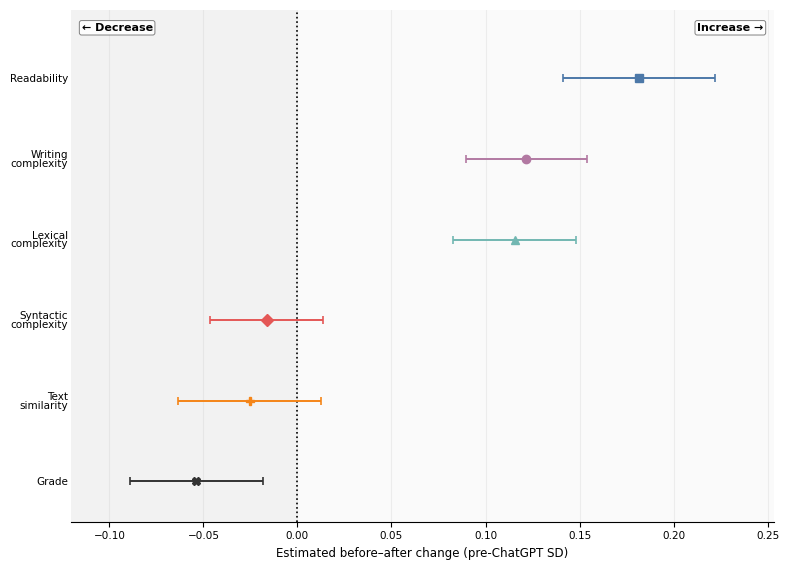

In [15]:
fig, ax = plt.subplots(
    figsize=(8.0, 5.8)
)

draw_panel_a(
    ax
)

plt.tight_layout()

fig.savefig(
    PLOT_PATH
    / "figure2_panel_a_prepost_model.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PLOT_PATH
    / "figure2_panel_a_prepost_model.pdf",
    bbox_inches="tight",
)

plt.show()

### Panel B — directional redistributed probability mass

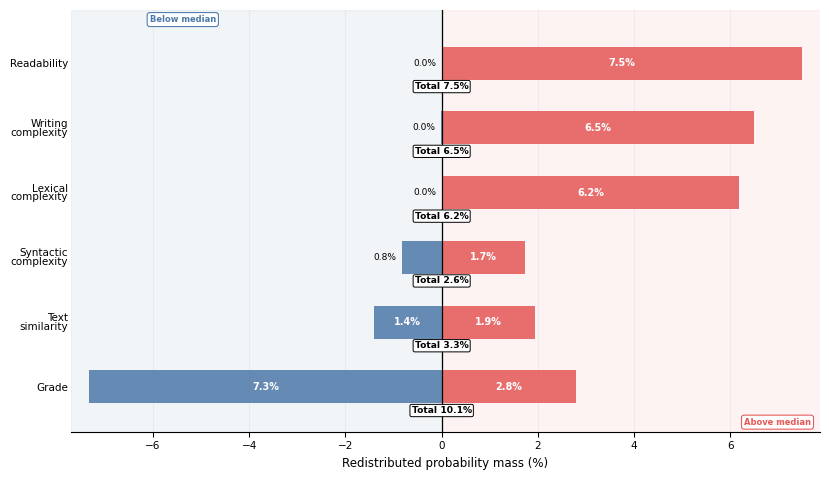

In [16]:
fig, ax = plt.subplots(
    figsize=(8.4, 4.9)
)

draw_panel_b(
    ax
)

plt.tight_layout()

resid_suffix = (
    "course_residualized"
    if RESIDUALIZE_WITHIN_COURSE
    else "raw"
)

fig.savefig(
    PLOT_PATH
    / f"figure2_panel_b_redistributed_mass_{resid_suffix}.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PLOT_PATH
    / f"figure2_panel_b_redistributed_mass_{resid_suffix}.pdf",
    bbox_inches="tight",
)

plt.show()

### Panel C — period-specific standardized outcome models

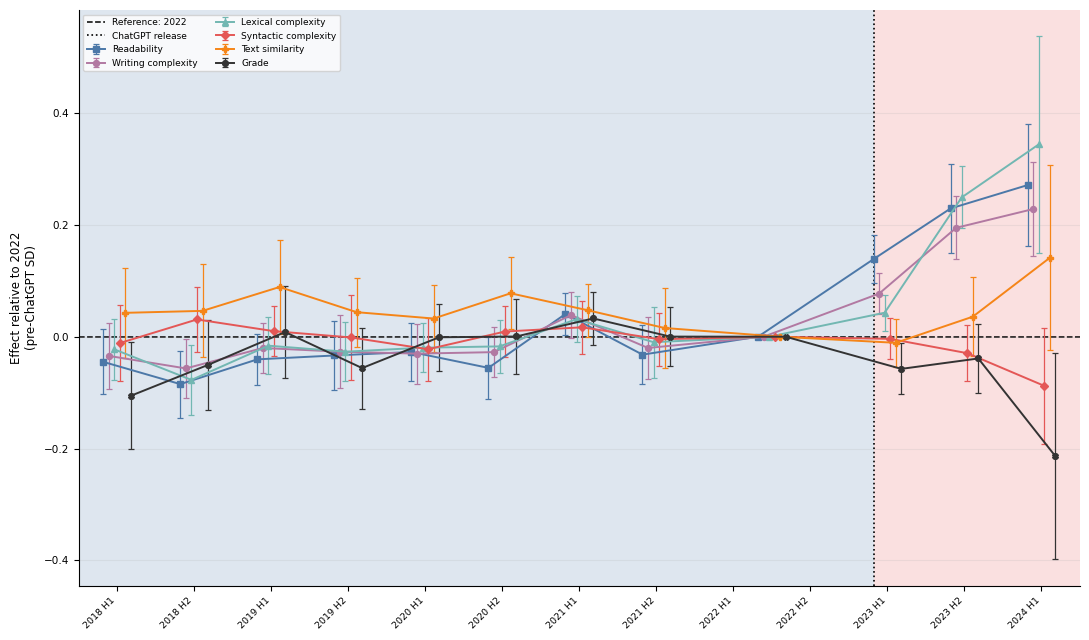

In [17]:
fig, ax = plt.subplots(
    figsize=(11, 6.5)
)

draw_panel_c(
    ax
)

plt.tight_layout()

fig.savefig(
    PLOT_PATH
    / "figure2_panel_c_standardized_all_outcomes_event_study.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PLOT_PATH
    / "figure2_panel_c_standardized_all_outcomes_event_study.pdf",
    bbox_inches="tight",
)

plt.show()

### Panel D — change in within-course dispersion

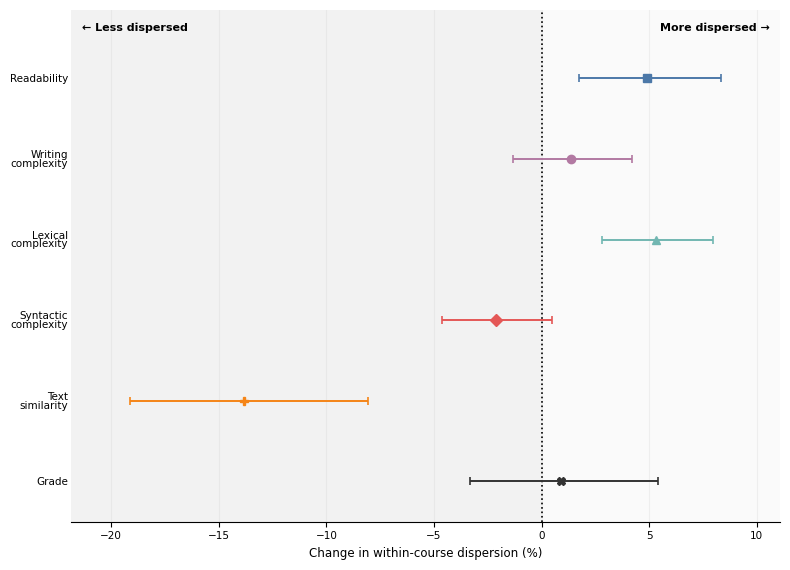

In [18]:
fig, ax = plt.subplots(
    figsize=(8.0, 5.8)
)

draw_panel_d(
    ax
)

plt.tight_layout()

fig.savefig(
    PLOT_PATH
    / "figure2_panel_d_dispersion_change.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    PLOT_PATH
    / "figure2_panel_d_dispersion_change.pdf",
    bbox_inches="tight",
)

plt.show()

### Combined Figure 2

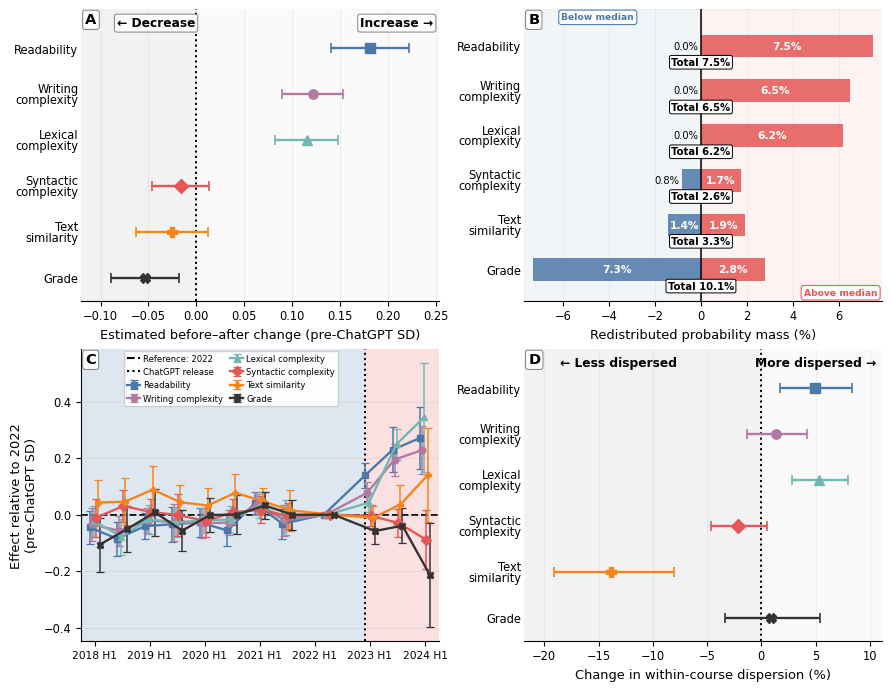

In [19]:
# ================================================================
# COMBINED FIGURE 2
# ================================================================
#
# Same physical figure size as Figure 1:
#     figsize = (8.8, 6.8)
#
# A, B and D deliberately share:
#   - the same outcome order,
#   - the same compact y-axis labels,
#   - the same y-label font size and line spacing.
# ================================================================

fig, axes = plt.subplots(
    2,
    2,
    figsize=(8.8, 6.8),
    layout="constrained",
)

ax_a = axes[
    0,
    0,
]

ax_b = axes[
    0,
    1,
]

ax_c = axes[
    1,
    0,
]

ax_d = axes[
    1,
    1,
]


# ================================================================
# DRAW PANELS
# ================================================================

draw_panel_a(
    ax_a,
    panel_label="A",
)

draw_panel_b(
    ax_b,
    panel_label="B",
)

draw_panel_c(
    ax_c,
    panel_label="C",
)

draw_panel_d(
    ax_d,
    panel_label="D",
)


# ================================================================
# PANEL C:
# SPARSE HORIZONTAL TIME LABELS, MATCHING FIGURE 1
# ================================================================

(
    plot_periods,
    x_time,
    chatgpt_x,
) = get_time_plot_positions(
    period_order
)

time_labels = (
    plot_periods[
        PERIOD_COL
    ]
    .reset_index(
        drop=True
    )
)

tick_positions = list(
    range(
        0,
        len(
            time_labels
        ),
        2,
    )
)

if (
    len(
        time_labels
    )
    - 1
    not in tick_positions
):

    tick_positions.append(
        len(
            time_labels
        )
        - 1
    )


ax_c.set_xticks(
    tick_positions
)

ax_c.set_xticklabels(
    [
        time_labels.iloc[
            i
        ]
        for i
        in tick_positions
    ],
    rotation=0,
    ha="center",
    fontsize=7.0,
)


# ================================================================
# READABILITY BOOST
# ================================================================

TEXT_SCALE = 1.10
LINE_SCALE = 1.20
MARKER_SCALE = 1.12


for ax in axes.flat:

    ax.xaxis.label.set_fontsize(
        ax.xaxis.label.get_fontsize()
        * TEXT_SCALE
    )

    ax.yaxis.label.set_fontsize(
        ax.yaxis.label.get_fontsize()
        * TEXT_SCALE
    )


    for tick_label in (
        list(
            ax.get_xticklabels()
        )
        + list(
            ax.get_yticklabels()
        )
    ):

        tick_label.set_fontsize(
            tick_label.get_fontsize()
            * TEXT_SCALE
        )


    for text_artist in ax.texts:

        text_artist.set_fontsize(
            text_artist.get_fontsize()
            * TEXT_SCALE
        )


    for line in ax.lines:

        line.set_linewidth(
            line.get_linewidth()
            * LINE_SCALE
        )

        if (
            line.get_markersize()
            > 0
        ):

            line.set_markersize(
                line.get_markersize()
                * MARKER_SCALE
            )


    for collection in ax.collections:

        try:

            current_widths = (
                collection.get_linewidths()
            )

            if (
                len(
                    current_widths
                )
                > 0
            ):

                collection.set_linewidths(
                    current_widths
                    * LINE_SCALE
                )

        except Exception:

            pass


# Keep panel labels identical after global text scaling.
for ax, label in zip(
    axes.flat,
    [
        "A",
        "B",
        "C",
        "D",
    ],
):

    for text_artist in ax.texts:

        if (
            text_artist.get_text()
            == label
        ):

            text_artist.set_fontsize(
                10.5
            )

            text_artist.set_fontweight(
                "bold"
            )


# ================================================================
# PANEL C LEGEND
# ================================================================

handles_c, labels_c = (
    ax_c.get_legend_handles_labels()
)

legend_c = ax_c.legend(
    handles_c,
    labels_c,
    frameon=True,
    ncol=2,
    loc="upper left",
    bbox_to_anchor=(
        0.12,
        0.995,
    ),
    fontsize=6.1,
    borderaxespad=0.0,
    columnspacing=0.8,
    handlelength=1.5,
    handletextpad=0.4,
)

legend_c.get_frame().set_alpha(
    0.94
)

legend_c.get_frame().set_facecolor(
    "white"
)


for handle in legend_c.legend_handles:

    try:

        handle.set_linewidth(
            1.5
        )

    except Exception:

        pass

    try:

        handle.set_markersize(
            4.5
        )

    except Exception:

        pass


# ================================================================
# SAVE MAIN FIGURE
# ================================================================

fig.savefig(
    PLOT_PATH
    / "gai_effects_figure2_combined.png",
    dpi=600,
    bbox_inches="tight",
)

fig.savefig(
    PLOT_PATH
    / "gai_effects_figure2_combined.pdf",
    bbox_inches="tight",
)

plt.show()

## Supplementary Information outputs

### Raw-outcome models used for SI robustness tables and the raw-grade event study

These models repeat the main pooled and period-specific specifications using the stored outcome variables rather than the pre-ChatGPT-SD standardized versions.

In [20]:
# ================================================================
# SI: RAW-OUTCOME MODELS
# ================================================================

raw_prepost_models = {}
raw_period_models = {}


for outcome in MODEL_OUTCOMES:

    raw_prepost_models[
        outcome
    ] = pf.feols(
        (
            f"{outcome} ~ "
            f"after | {COURSE_COL}"
        ),
        data=analysis_data,
        vcov={
            "CRV1": COURSE_COL
        },
    )

    raw_period_models[
        outcome
    ] = pf.feols(
        (
            f"{outcome} ~ "
            f"{model2_rhs} "
            f"| {COURSE_COL}"
        ),
        data=model2_data,
        vcov={
            "CRV1": COURSE_COL
        },
    )

### SI figure — grade event study in original grade-category units

The main Figure 2C includes grades on the common standardized scale. For substantive interpretation, this SI figure shows the same period-specific course-fixed-effects estimates for grades on the original recoded 0–6 grade-category scale.

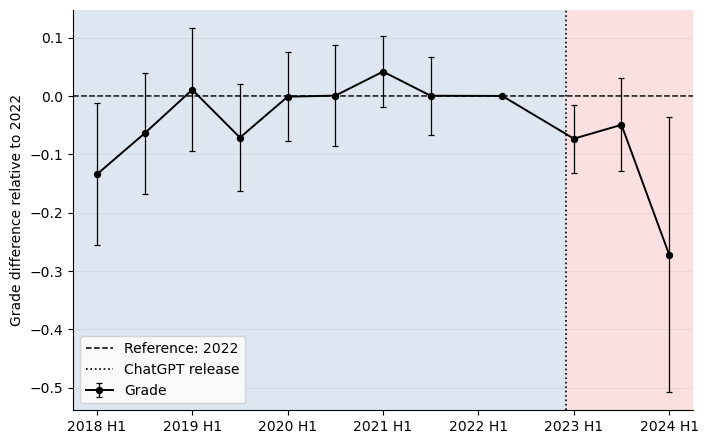

In [21]:
# ================================================================
# SI FIGURE:
# RAW GRADE EVENT STUDY
# ================================================================

raw_grade_model = (
    raw_period_models[
        GRADE_OUTCOME
    ]
)

raw_grade_tidy = (
    raw_grade_model
    .tidy()
)

raw_grade_effect_rows = [
    {
        "plot_position":
            reference_plot_position,
        "estimate":
            0.0,
        "ci_low":
            0.0,
        "ci_high":
            0.0,
    }
]


for period_index in period_order[
    "model_period_index"
]:

    if (
        period_index
        in reference_period_indices
    ):
        continue

    var = (
        period_dummy_vars[
            period_index
        ]
    )

    row = (
        raw_grade_tidy
        .loc[
            var
        ]
    )

    raw_grade_effect_rows.append(
        {
            "plot_position":
                float(
                    period_index
                ),
            "estimate":
                row[
                    "Estimate"
                ],
            "ci_low":
                row[
                    "2.5%"
                ],
            "ci_high":
                row[
                    "97.5%"
                ],
        }
    )


raw_grade_effects = (
    pd.DataFrame(
        raw_grade_effect_rows
    )
    .sort_values(
        "plot_position"
    )
)


(
    si_plot_periods,
    si_x,
    si_chatgpt_x,
) = get_time_plot_positions(
    period_order
)


fig, ax = plt.subplots(
    figsize=(8.0, 5.2)
)


shade_pre_post(
    ax=ax,
    n_periods=len(
        si_plot_periods
    ),
    split_x=si_chatgpt_x,
)


ax.axhline(
    0,
    color="black",
    linestyle="--",
    linewidth=1.1,
    label=(
        f"Reference: "
        f"{reference_period_label}"
    ),
    zorder=1,
)


estimates = (
    raw_grade_effects[
        "estimate"
    ]
    .to_numpy()
)

ci_low = (
    raw_grade_effects[
        "ci_low"
    ]
    .to_numpy()
)

ci_high = (
    raw_grade_effects[
        "ci_high"
    ]
    .to_numpy()
)


ax.errorbar(
    raw_grade_effects[
        "plot_position"
    ],
    estimates,
    yerr=np.vstack(
        [
            estimates
            - ci_low,
            ci_high
            - estimates,
        ]
    ),
    marker="o",
    linestyle="-",
    color="black",
    ecolor="black",
    linewidth=1.4,
    markersize=4.3,
    elinewidth=0.9,
    capsize=2.3,
    capthick=0.9,
    label="Grade",
    zorder=3,
)


ax.axvline(
    si_chatgpt_x,
    color="black",
    linestyle=":",
    linewidth=1.2,
    label="ChatGPT release",
    zorder=2,
)


si_time_labels = (
    si_plot_periods[
        PERIOD_COL
    ]
    .reset_index(
        drop=True
    )
)

si_tick_positions = list(
    range(
        0,
        len(
            si_time_labels
        ),
        2,
    )
)

if (
    len(
        si_time_labels
    )
    - 1
    not in si_tick_positions
):

    si_tick_positions.append(
        len(
            si_time_labels
        )
        - 1
    )


ax.set_xticks(
    si_tick_positions
)

ax.set_xticklabels(
    [
        si_time_labels.iloc[
            i
        ]
        for i
        in si_tick_positions
    ],
    rotation=0,
    ha="center",
)


ax.set_ylabel(
    (
        f"Grade difference relative to "
        f"{reference_period_label}"
    )
)

format_time_axis(
    ax
)

ax.set_xlim(
    -0.5,
    len(
        si_plot_periods
    )
    - 0.5,
)

ax.legend(
    frameon=True,
    loc="lower left",
)


fig.savefig(
    APPENDIX_PATH
    / "SI_grade_event_study_raw_units.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    APPENDIX_PATH
    / "SI_grade_event_study_raw_units.pdf",
    bbox_inches="tight",
)

plt.show()

### SI figure — unadjusted half-year timelines

Bootstrap unadjusted timelines:   0%|          | 0/1000 [00:00<?, ?it/s]

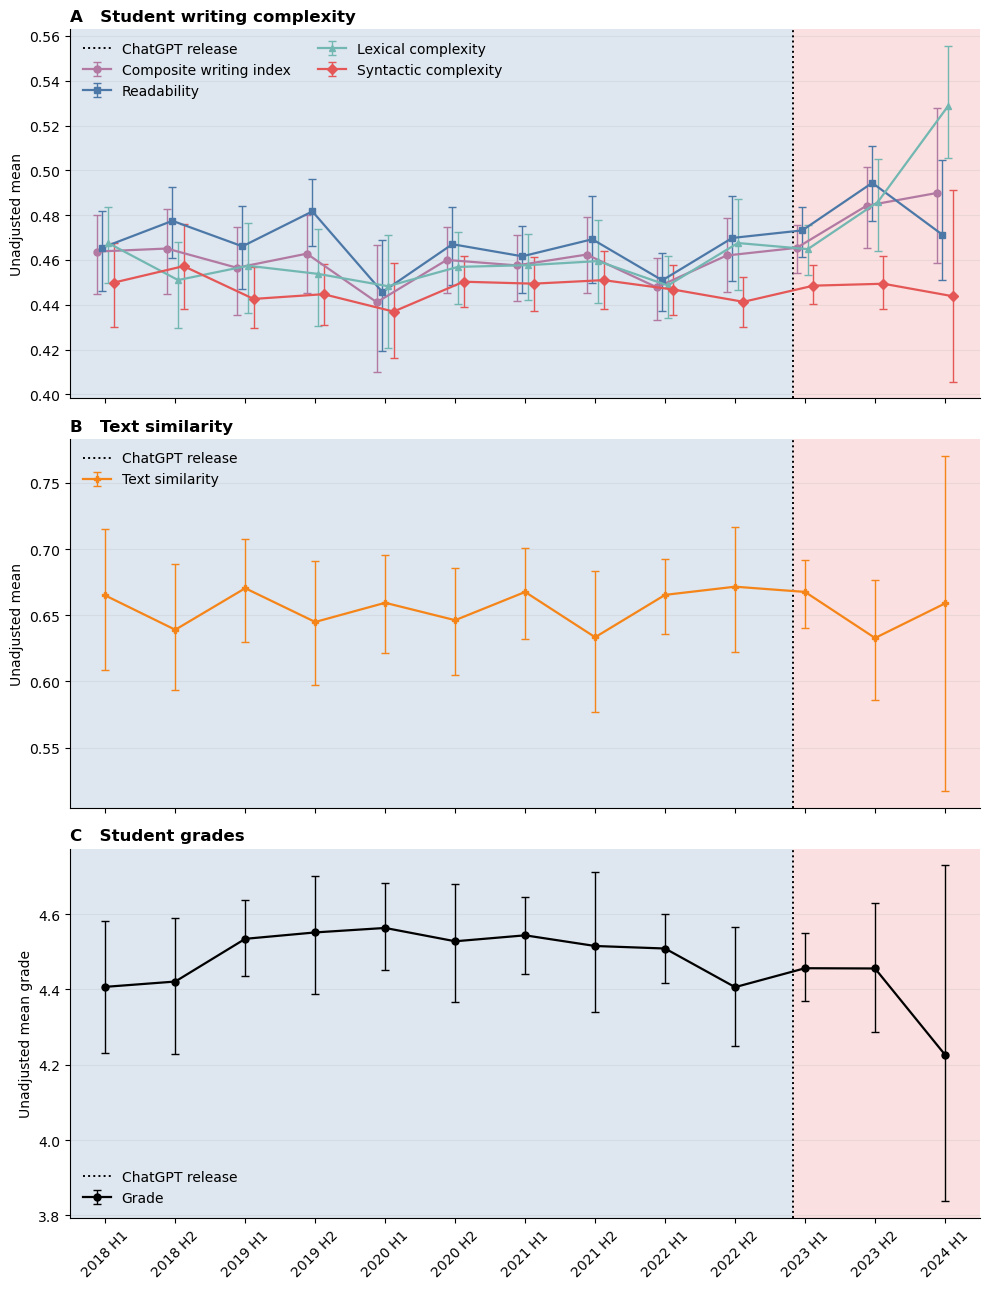

In [22]:
# ================================================================
# SUPPLEMENTARY INFORMATION FIGURE:
# UNADJUSTED HALF-YEAR TIMELINES
# ================================================================

# This figure uses raw, unadjusted period means.
# Uncertainty is estimated with a nonparametric course-cluster
# bootstrap, resampling complete courses with replacement.

UNADJUSTED_OUTCOMES = [
    *OUTCOME_COLS,
    GRADE_OUTCOME,
]


# ================================================================
# 1. OBSERVED UNADJUSTED HALF-YEAR MEANS
# ================================================================

unadjusted_timeline = (
    analysis_data
    .groupby(
        [
            PERIOD_START_COL,
            PERIOD_COL,
        ],
        as_index=False,
    )
    .agg(
        **{
            f"{outcome}_mean": (
                outcome,
                "mean",
            )
            for outcome
            in UNADJUSTED_OUTCOMES
        },
        **{
            f"{outcome}_n": (
                outcome,
                "count",
            )
            for outcome
            in UNADJUSTED_OUTCOMES
        },
    )
    .sort_values(
        PERIOD_START_COL
    )
    .reset_index(drop=True)
)


# ================================================================
# 2. COMMON PERIOD AND COURSE ORDER
# ================================================================

periods = (
    unadjusted_timeline[
        PERIOD_START_COL
    ]
    .tolist()
)

cluster_ids = pd.Index(
    analysis_data[
        COURSE_COL
    ]
    .dropna()
    .unique()
)

n_clusters = len(
    cluster_ids
)

n_periods = len(
    periods
)


# ================================================================
# 3. PREPARE COURSE × PERIOD SUMS AND COUNTS
# ================================================================

bootstrap_inputs = {}

for outcome in UNADJUSTED_OUTCOMES:

    course_period = (
        analysis_data[
            [
                COURSE_COL,
                PERIOD_START_COL,
                outcome,
            ]
        ]
        .dropna(
            subset=[
                COURSE_COL,
                PERIOD_START_COL,
                outcome,
            ]
        )
        .groupby(
            [
                COURSE_COL,
                PERIOD_START_COL,
            ],
            as_index=False,
        )
        .agg(
            outcome_sum=(
                outcome,
                "sum",
            ),
            outcome_count=(
                outcome,
                "count",
            ),
        )
    )

    sum_matrix = (
        course_period
        .pivot(
            index=COURSE_COL,
            columns=PERIOD_START_COL,
            values="outcome_sum",
        )
        .reindex(
            index=cluster_ids,
            columns=periods,
        )
        .fillna(0.0)
        .to_numpy()
    )

    count_matrix = (
        course_period
        .pivot(
            index=COURSE_COL,
            columns=PERIOD_START_COL,
            values="outcome_count",
        )
        .reindex(
            index=cluster_ids,
            columns=periods,
        )
        .fillna(0.0)
        .to_numpy()
    )

    bootstrap_inputs[
        outcome
    ] = {
        "sum": sum_matrix,
        "count": count_matrix,
    }


# ================================================================
# 4. COURSE-CLUSTER BOOTSTRAP
# ================================================================

rng = np.random.default_rng(
    BOOTSTRAP_SEED
)

bootstrap_means = {
    outcome: np.full(
        (
            N_BOOT,
            n_periods,
        ),
        np.nan,
    )
    for outcome
    in UNADJUSTED_OUTCOMES
}


for b in tqdm(
    range(N_BOOT),
    desc="Bootstrap unadjusted timelines",
):

    # Resample complete courses with replacement.
    sampled_clusters = rng.choice(
        n_clusters,
        size=n_clusters,
        replace=True,
    )

    cluster_weights = np.bincount(
        sampled_clusters,
        minlength=n_clusters,
    ).astype(float)

    for outcome in UNADJUSTED_OUTCOMES:

        sum_matrix = (
            bootstrap_inputs[
                outcome
            ][
                "sum"
            ]
        )

        count_matrix = (
            bootstrap_inputs[
                outcome
            ][
                "count"
            ]
        )

        period_sums = (
            cluster_weights
            @ sum_matrix
        )

        period_counts = (
            cluster_weights
            @ count_matrix
        )

        bootstrap_means[
            outcome
        ][
            b,
            :
        ] = np.divide(
            period_sums,
            period_counts,
            out=np.full(
                n_periods,
                np.nan,
            ),
            where=(
                period_counts > 0
            ),
        )


# ================================================================
# 5. 95% PERCENTILE CONFIDENCE INTERVALS
# ================================================================

for outcome in UNADJUSTED_OUTCOMES:

    unadjusted_timeline[
        f"{outcome}_ci_low"
    ] = np.nanpercentile(
        bootstrap_means[
            outcome
        ],
        2.5,
        axis=0,
    )

    unadjusted_timeline[
        f"{outcome}_ci_high"
    ] = np.nanpercentile(
        bootstrap_means[
            outcome
        ],
        97.5,
        axis=0,
    )


# ================================================================
# 6. COMMON PLOT POSITIONS
# ================================================================

(
    plot_data,
    x,
    chatgpt_x,
) = get_time_plot_positions(
    unadjusted_timeline
)


# ================================================================
# 7. FIGURE
# ================================================================

fig, axes = plt.subplots(
    3,
    1,
    figsize=(10, 13),
    sharex=True,
)


# ================================================================
# PANEL A: WRITING COMPLEXITY
# ================================================================

ax = axes[0]

shade_pre_post(
    ax=ax,
    n_periods=len(
        plot_data
    ),
    split_x=chatgpt_x,
)


complexity_outcomes = {
    outcome: label
    for outcome, label
    in OUTCOMES.items()
    if outcome
    != "cosine_similarity_full"
}


offset_values = np.linspace(
    -0.12,
    0.12,
    len(
        complexity_outcomes
    ),
)

outcome_offsets = dict(
    zip(
        complexity_outcomes.keys(),
        offset_values,
    )
)


for outcome, label in complexity_outcomes.items():

    x_plot = (
        x
        + outcome_offsets[
            outcome
        ]
    )

    means = (
        plot_data[
            f"{outcome}_mean"
        ]
        .to_numpy()
    )

    ci_low = (
        plot_data[
            f"{outcome}_ci_low"
        ]
        .to_numpy()
    )

    ci_high = (
        plot_data[
            f"{outcome}_ci_high"
        ]
        .to_numpy()
    )

    yerr = np.vstack([
        means - ci_low,
        ci_high - means,
    ])

    ax.errorbar(
        x_plot,
        means,
        yerr=yerr,
        marker=OUTCOME_MARKERS[
            outcome
        ],
        linestyle="-",
        color=OUTCOME_COLORS[
            outcome
        ],
        ecolor=OUTCOME_COLORS[
            outcome
        ],
        linewidth=1.6,
        markersize=5,
        elinewidth=1.0,
        capsize=2.8,
        capthick=1.0,
        label=label,
        zorder=3,
    )


ax.axvline(
    chatgpt_x,
    color="black",
    linestyle=":",
    linewidth=1.4,
    label="ChatGPT release",
    zorder=2,
)


ax.set_ylabel(
    "Unadjusted mean"
)

ax.set_title(
    "A   Student writing complexity",
    loc="left",
    fontweight="bold",
)

format_time_axis(
    ax
)

ax.legend(
    frameon=False,
    ncol=2,
    loc="best",
)

ax.set_xlim(
    -0.5,
    len(plot_data) - 0.5,
)


# ================================================================
# PANEL B: TEXT SIMILARITY
# ================================================================

ax = axes[1]

shade_pre_post(
    ax=ax,
    n_periods=len(
        plot_data
    ),
    split_x=chatgpt_x,
)


similarity_outcome = (
    "cosine_similarity_full"
)

means = (
    plot_data[
        f"{similarity_outcome}_mean"
    ]
    .to_numpy()
)

ci_low = (
    plot_data[
        f"{similarity_outcome}_ci_low"
    ]
    .to_numpy()
)

ci_high = (
    plot_data[
        f"{similarity_outcome}_ci_high"
    ]
    .to_numpy()
)

yerr = np.vstack([
    means - ci_low,
    ci_high - means,
])


ax.errorbar(
    x,
    means,
    yerr=yerr,
    marker=OUTCOME_MARKERS[
        similarity_outcome
    ],
    linestyle="-",
    color=OUTCOME_COLORS[
        similarity_outcome
    ],
    ecolor=OUTCOME_COLORS[
        similarity_outcome
    ],
    linewidth=1.6,
    markersize=5,
    elinewidth=1.0,
    capsize=2.8,
    capthick=1.0,
    label="Text similarity",
    zorder=3,
)


ax.axvline(
    chatgpt_x,
    color="black",
    linestyle=":",
    linewidth=1.4,
    label="ChatGPT release",
    zorder=2,
)


ax.set_ylabel(
    "Unadjusted mean"
)

ax.set_title(
    "B   Text similarity",
    loc="left",
    fontweight="bold",
)

format_time_axis(
    ax
)

ax.legend(
    frameon=False,
    loc="best",
)

ax.set_xlim(
    -0.5,
    len(plot_data) - 0.5,
)


# ================================================================
# PANEL C: GRADES
# ================================================================

ax = axes[2]

shade_pre_post(
    ax=ax,
    n_periods=len(
        plot_data
    ),
    split_x=chatgpt_x,
)


mean_grade = (
    plot_data[
        f"{GRADE_OUTCOME}_mean"
    ]
    .to_numpy()
)

ci_low = (
    plot_data[
        f"{GRADE_OUTCOME}_ci_low"
    ]
    .to_numpy()
)

ci_high = (
    plot_data[
        f"{GRADE_OUTCOME}_ci_high"
    ]
    .to_numpy()
)

yerr = np.vstack([
    mean_grade - ci_low,
    ci_high - mean_grade,
])


ax.errorbar(
    x,
    mean_grade,
    yerr=yerr,
    marker="o",
    linestyle="-",
    color="black",
    ecolor="black",
    linewidth=1.6,
    markersize=5,
    elinewidth=1.0,
    capsize=2.8,
    capthick=1.0,
    label="Grade",
    zorder=3,
)


ax.axvline(
    chatgpt_x,
    color="black",
    linestyle=":",
    linewidth=1.4,
    label="ChatGPT release",
    zorder=2,
)


ax.set_ylabel(
    "Unadjusted mean grade"
)

ax.set_title(
    "C   Student grades",
    loc="left",
    fontweight="bold",
)


ax.set_xticks(
    x
)

ax.set_xticklabels(
    plot_data[
        PERIOD_COL
    ],
    rotation=45,
)


format_time_axis(
    ax
)

ax.legend(
    frameon=False,
    loc="best",
)

ax.set_xlim(
    -0.5,
    len(plot_data) - 0.5,
)


# ================================================================
# 8. SAVE
# ================================================================

plt.tight_layout()

fig.savefig(
    APPENDIX_PATH
    / "SI_unadjusted_half_year_timelines.png",
    dpi=300,
    bbox_inches="tight",
)

fig.savefig(
    APPENDIX_PATH
    / "SI_unadjusted_half_year_timelines.pdf",
    bbox_inches="tight",
)

plt.show()

### SI figures — pre/post outcome distributions

In [23]:
# ================================================================
# SUPPLEMENTARY INFORMATION DISTRIBUTION PLOTS
#
# For each outcome, create TWO plots:
#
#   1. Analysis-scale distribution
#      - uses rpm_density_data
#      - standardized by pre-ChatGPT SD
#      - course-adjusted only if RESIDUALIZE_WITHIN_COURSE = True
#
#   2. Raw distribution
#      - original observed outcome values
#      - no residualization
#      - no standardization
#
# Both use the same Figure-1C-style decomposition.
# ================================================================

from scipy.stats import gaussian_kde


# ------------------------------------------------
# Output directories
# ------------------------------------------------

# All SI outputs are written directly to APPENDIX_PATH.
ANALYSIS_SCALE_PATH = APPENDIX_PATH
RAW_DISTRIBUTION_PATH = APPENDIX_PATH



# ================================================================
# Helper function:
# Figure-1C-style distribution plot
# ================================================================

def plot_distribution_decomposition(
    *,
    x,
    pre_density,
    post_density,
    shared_density,
    pre_excess_density,
    post_excess_density,
    pre_median,
    redistributed_percent,
    left_percent,
    right_percent,
    label,
    xlabel,
    output_path,
    filename,
):

    fig, ax = plt.subplots(
        figsize=(6.8, 4.6)
    )


    # ------------------------------------------------
    # Shared probability mass
    # ------------------------------------------------

    ax.fill_between(
        x,
        0,
        shared_density,
        color="#D9D9D9",
        alpha=0.75,
        label="Shared probability mass",
        zorder=1,
    )


    # ------------------------------------------------
    # Pre-period excess
    # ------------------------------------------------

    ax.fill_between(
        x,
        post_density,
        pre_density,
        where=(
            pre_density
            > post_density
        ),
        interpolate=True,
        color=COLORS["before"],
        alpha=0.30,
        label="Pre-ChatGPT excess",
        zorder=2,
    )


    # ------------------------------------------------
    # Post-period excess
    # ------------------------------------------------

    ax.fill_between(
        x,
        pre_density,
        post_density,
        where=(
            post_density
            > pre_density
        ),
        interpolate=True,
        color=COLORS["after"],
        alpha=0.30,
        label="Post-ChatGPT excess",
        zorder=2,
    )


    # ------------------------------------------------
    # Density lines
    # ------------------------------------------------

    ax.plot(
        x,
        pre_density,
        color=COLORS["before"],
        linewidth=1.7,
        label="Pre-ChatGPT",
        zorder=4,
    )

    ax.plot(
        x,
        post_density,
        color=COLORS["after"],
        linewidth=1.7,
        label="Post-ChatGPT",
        zorder=4,
    )


    # ------------------------------------------------
    # Pre-period median
    # ------------------------------------------------

    ax.axvline(
        pre_median,
        color="black",
        linestyle=":",
        linewidth=1.0,
        zorder=3,
    )


    # ------------------------------------------------
    # Summary box
    # ------------------------------------------------

    summary_text = (
        f"Redistributed mass: {redistributed_percent:.1f}%\n"
        f"Below pre median: {left_percent:.1f}%\n"
        f"Above pre median: {right_percent:.1f}%"
    )

    ax.text(
        0.98,
        0.96,
        summary_text,
        transform=ax.transAxes,
        ha="right",
        va="top",
        fontsize=8,
        color="black",
        bbox={
            "boxstyle": "round,pad=0.35",
            "facecolor": "white",
            "edgecolor": "black",
            "linewidth": 0.7,
            "alpha": 0.95,
        },
        zorder=10,
    )


    # ------------------------------------------------
    # Formatting
    # ------------------------------------------------

    ax.set_xlabel(
        xlabel
    )

    ax.set_ylabel(
        "Density"
    )

    ax.spines["top"].set_visible(False)
    ax.spines["right"].set_visible(False)

    ax.legend(
        frameon=False,
        fontsize=7.5,
        loc="upper left",
    )

    plt.tight_layout()


    # ------------------------------------------------
    # Save
    # ------------------------------------------------

    fig.savefig(
        output_path
        / f"{filename}.png",
        dpi=300,
        bbox_inches="tight",
    )

    fig.savefig(
        output_path
        / f"{filename}.pdf",
        bbox_inches="tight",
    )

    plt.show()

#### Analysis-scale distribution decompositions

These plots use the same standardized analysis scale as Panel B and decompose the pre/post density overlap into shared and redistributed probability mass.

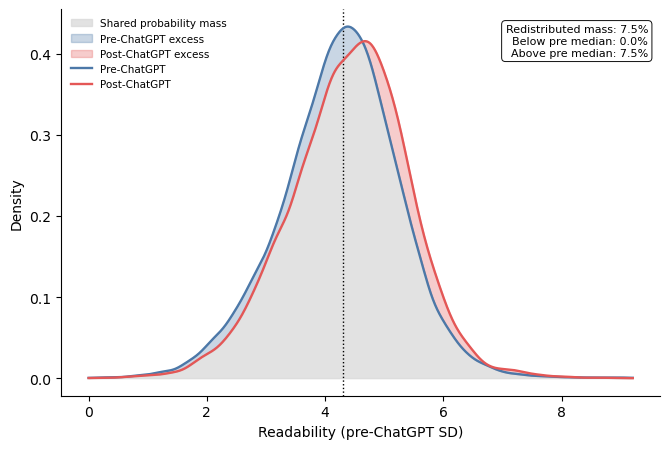

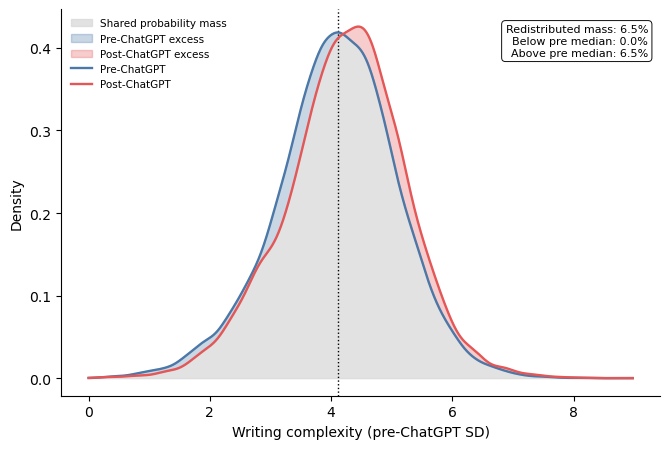

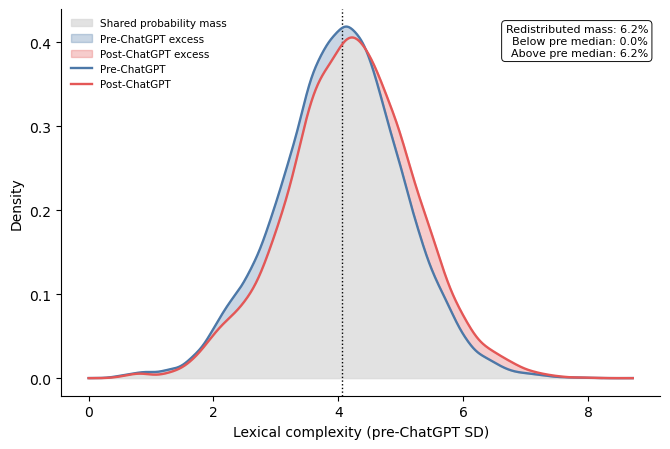

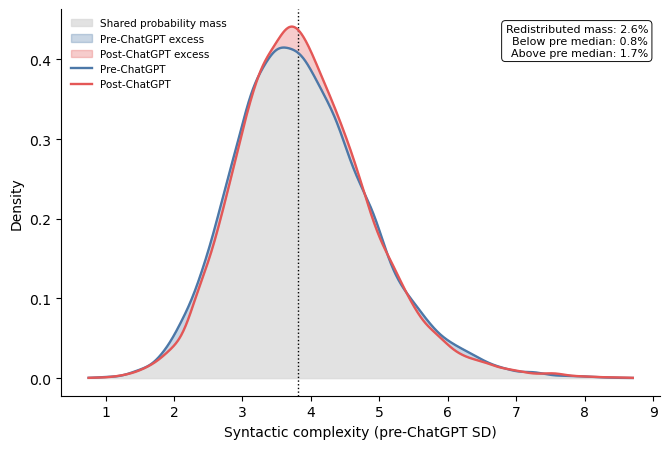

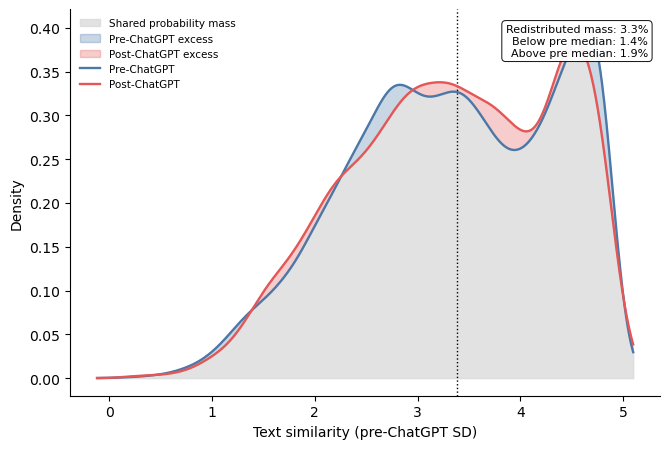

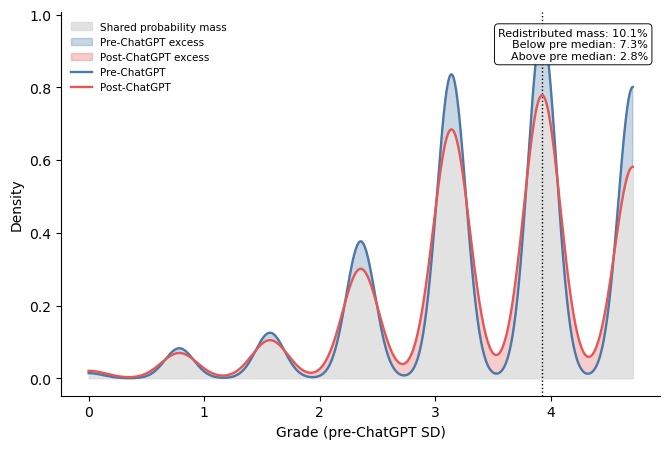

In [24]:
# ================================================================
# 1. ANALYSIS-SCALE DISTRIBUTIONS
# ================================================================

for outcome, density_info in rpm_density_data.items():

    label = (
        density_info["label"]
    )

    x = (
        density_info["x"]
    )

    pre_density = (
        density_info["pre_density"]
    )

    post_density = (
        density_info["post_density"]
    )

    shared_density = (
        density_info["shared_density"]
    )

    pre_excess_density = (
        density_info["pre_excess_density"]
    )

    post_excess_density = (
        density_info["post_excess_density"]
    )

    pre_median = (
        density_info["pre_median"]
    )

    redistributed_percent = (
        density_info["redistributed_percent"]
    )

    left_percent = (
        density_info["left_percent"]
    )

    right_percent = (
        density_info["right_percent"]
    )


    # ------------------------------------------------
    # Axis label depends on residualization switch
    # ------------------------------------------------

    if RESIDUALIZE_WITHIN_COURSE:

        xlabel = (
            f"{label} "
            "(course-adjusted, pre-ChatGPT SD)"
        )

        suffix = (
            "course_residualized_standardized"
        )

    else:

        xlabel = (
            f"{label} "
            "(pre-ChatGPT SD)"
        )

        suffix = (
            "standardized"
        )


    filename = (
        "SI_distribution_"
        + label
          .lower()
          .replace(" ", "_")
        + f"_{suffix}"
    )


    plot_distribution_decomposition(
        x=x,
        pre_density=pre_density,
        post_density=post_density,
        shared_density=shared_density,
        pre_excess_density=pre_excess_density,
        post_excess_density=post_excess_density,
        pre_median=pre_median,
        redistributed_percent=redistributed_percent,
        left_percent=left_percent,
        right_percent=right_percent,
        label=label,
        xlabel=xlabel,
        output_path=ANALYSIS_SCALE_PATH,
        filename=filename,
    )

#### Raw observed distribution decompositions

These companion plots repeat the same decomposition using the stored outcome variables without standardization.

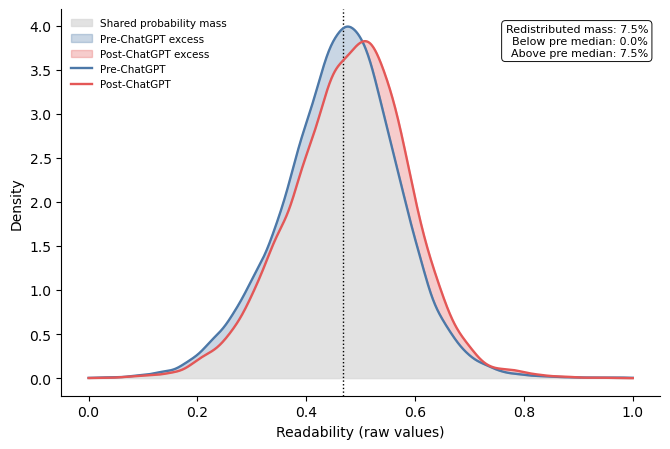

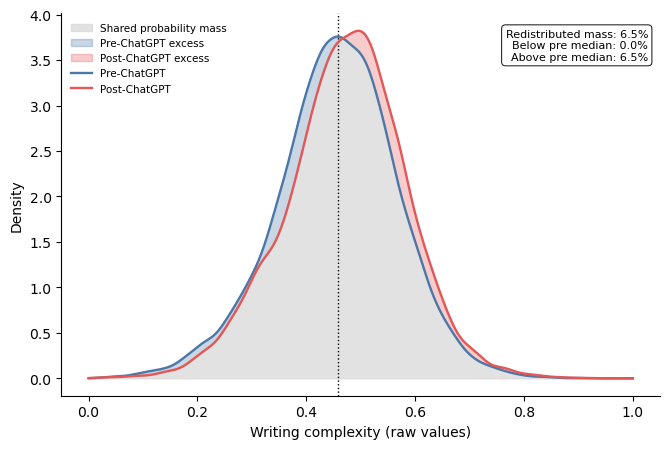

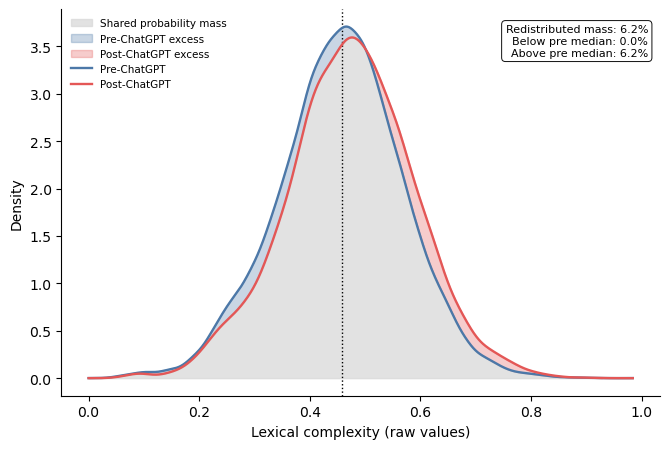

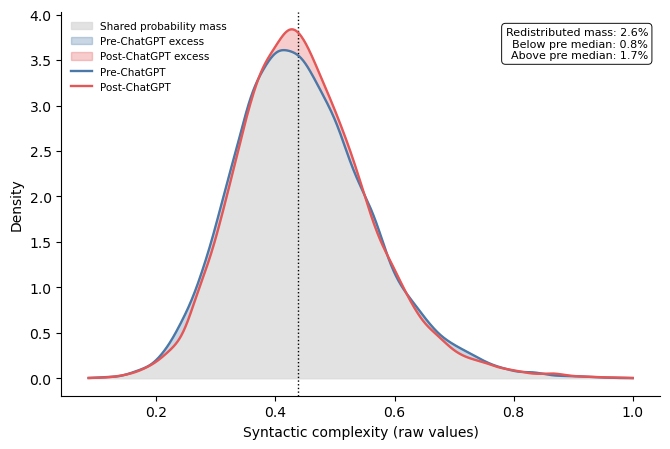

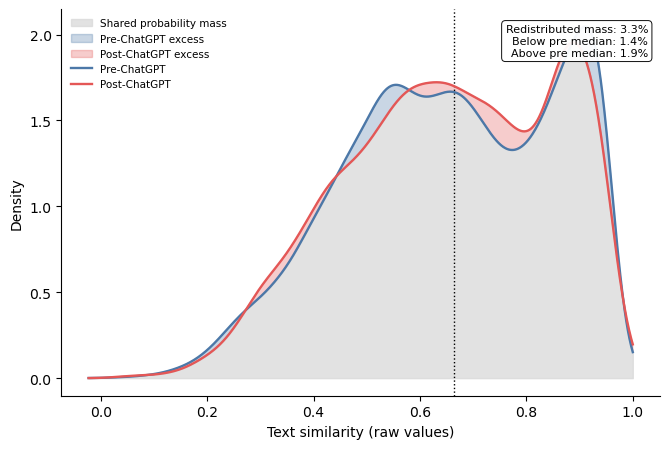

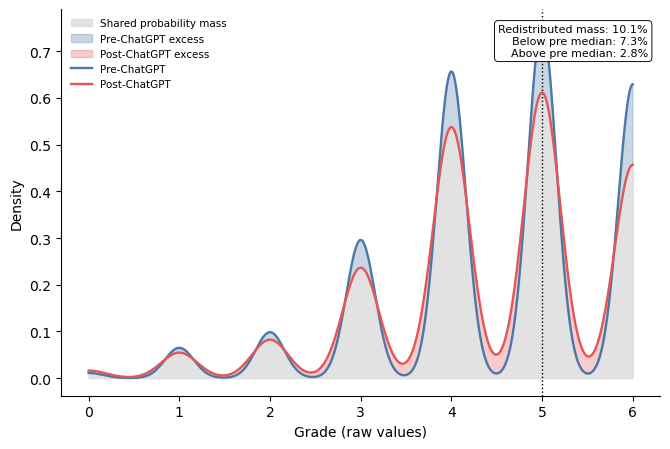

,outcome,label,pre_median,redistributed_percent,left_percent,right_percent
0,readability_index_norm,Readability,0.466887,7.491202,0.000000,7.491202
1,WQ_index_norm,Writing complexity,0.459188,6.506119,0.003596,6.502523
2,lexical_index_norm,Lexical complexity,0.458265,6.181892,0.000000,6.181892
3,syntactic_index_norm,Syntactic complexity,0.437365,2.550031,0.816018,1.734013
4,cosine_similarity_full,Text similarity,0.663352,3.347698,1.413575,1.934123
5,karakter_0_6,Grade,5.000000,10.124993,7.331143,2.793850


In [25]:
# ================================================================
# 2. RAW OBSERVED DISTRIBUTIONS
# ================================================================

raw_density_rows = []


for outcome, label in RPM_DIR_OUTCOMES.items():

    temp = (
        analysis_data[
            ["after", outcome]
        ]
        .dropna()
        .copy()
    )


    # ------------------------------------------------
    # Raw pre/post values
    # ------------------------------------------------

    pre_vals = (
        temp
        .loc[
            temp["after"] == 0,
            outcome,
        ]
        .to_numpy()
    )

    post_vals = (
        temp
        .loc[
            temp["after"] == 1,
            outcome,
        ]
        .to_numpy()
    )


    # ------------------------------------------------
    # Pre median
    # ------------------------------------------------

    pre_median = (
        np.median(pre_vals)
    )


    # ------------------------------------------------
    # Common grid
    # ------------------------------------------------

    x_min = min(
        pre_vals.min(),
        post_vals.min(),
    )

    x_max = max(
        pre_vals.max(),
        post_vals.max(),
    )

    base_grid = np.linspace(
        x_min,
        x_max,
        1000,
    )

    x = np.sort(
        np.unique(
            np.append(
                base_grid,
                pre_median,
            )
        )
    )


    # ------------------------------------------------
    # KDE
    # ------------------------------------------------

    pre_kde = gaussian_kde(
        pre_vals
    )

    post_kde = gaussian_kde(
        post_vals
    )

    pre_density = (
        pre_kde(x)
    )

    post_density = (
        post_kde(x)
    )


    # ------------------------------------------------
    # Shared and excess densities
    # ------------------------------------------------

    shared_density = np.minimum(
        pre_density,
        post_density,
    )

    pre_excess_density = np.maximum(
        pre_density - post_density,
        0,
    )

    post_excess_density = np.maximum(
        post_density - pre_density,
        0,
    )


    # ------------------------------------------------
    # Integrate
    # ------------------------------------------------

    redistributed_mass = np.trapezoid(
        post_excess_density,
        x,
    )


    # ------------------------------------------------
    # Split post excess around pre median
    # ------------------------------------------------

    left_mask = (
        x <= pre_median
    )

    right_mask = (
        x >= pre_median
    )


    left_excess = np.trapezoid(
        post_excess_density[left_mask],
        x[left_mask],
    )

    right_excess = np.trapezoid(
        post_excess_density[right_mask],
        x[right_mask],
    )


    redistributed_percent = (
        redistributed_mass
        * 100
    )

    left_percent = (
        left_excess
        * 100
    )

    right_percent = (
        right_excess
        * 100
    )


    # ------------------------------------------------
    # Save raw summary table
    # ------------------------------------------------

    raw_density_rows.append(
        {
            "outcome":
                outcome,

            "label":
                label,

            "pre_median":
                pre_median,

            "redistributed_percent":
                redistributed_percent,

            "left_percent":
                left_percent,

            "right_percent":
                right_percent,
        }
    )


    # ------------------------------------------------
    # Plot
    # ------------------------------------------------

    filename = (
        "SI_distribution_"
        + label
          .lower()
          .replace(" ", "_")
        + "_raw"
    )


    plot_distribution_decomposition(
        x=x,
        pre_density=pre_density,
        post_density=post_density,
        shared_density=shared_density,
        pre_excess_density=pre_excess_density,
        post_excess_density=post_excess_density,
        pre_median=pre_median,
        redistributed_percent=redistributed_percent,
        left_percent=left_percent,
        right_percent=right_percent,
        label=label,
        xlabel=f"{label} (raw values)",
        output_path=RAW_DISTRIBUTION_PATH,
        filename=filename,
    )


# ------------------------------------------------
# Raw-distribution summary
# ------------------------------------------------

raw_density_table = (
    pd.DataFrame(
        raw_density_rows
    )
)

display(
    raw_density_table
)

### SI tables — standardized and raw regression models

In [26]:
# ================================================================
# SI TABLE HELPER
# ================================================================

def write_si_etable(
    *,
    models,
    filename,
    caption,
    labels,
    keep=None,
    exact_match=False,
):
    """Display and save a publication-ready PyFixest SI table."""

    kwargs = {
        "model_heads":
            MODEL_OUTCOME_LABELS,
        "head_order":
            "h",
        "labels":
            labels,
        "felabels": {
            COURSE_COL: "Course",
        },
        "show_fe":
            True,
        "signif_code": [
            0.001,
            0.01,
            0.05,
        ],
        "caption":
            caption,
        "notes": (
            "Course fixed effects included. "
            "CRV1 standard errors clustered by course. "
            "* p < 0.05, ** p < 0.01, *** p < 0.001."
        ),
    }

    if keep is not None:
        kwargs[
            "keep"
        ] = keep

        kwargs[
            "exact_match"
        ] = exact_match


    table_gt = pf.etable(
        models,
        type="gt",
        **kwargs,
    )

    display(
        table_gt
    )


    table_tex = pf.etable(
        models,
        type="tex",
        **kwargs,
    )

    (
        APPENDIX_PATH
        / filename
    ).write_text(
        table_tex,
        encoding="utf-8",
    )


# ================================================================
# TABLE S?: STANDARDIZED BEFORE / AFTER
# ================================================================

write_si_etable(
    models=list(
        prepost_models.values()
    ),
    filename=(
        "SI_figure2_standardized_before_after_models.tex"
    ),
    caption=(
        "Standardized before--after course fixed-effects models "
        "for Figure 2. Outcomes are centered on their pre-ChatGPT "
        "means and divided by their pre-ChatGPT standard deviations."
    ),
    labels={
        "after": "After ChatGPT",
    },
    keep=[
        "after",
    ],
    exact_match=True,
)


# ================================================================
# TABLE S?: STANDARDIZED PERIOD-SPECIFIC
# ================================================================

write_si_etable(
    models=list(
        period_reference_models.values()
    ),
    filename=(
        "SI_figure2_standardized_period_models.tex"
    ),
    caption=(
        "Standardized period-specific course fixed-effects models "
        "for Figure 2. Outcomes are measured in pre-ChatGPT SD units. "
        f"The pooled {reference_period_label} observations form the "
        "reference period."
    ),
    labels=period_var_labels,
)


# ================================================================
# TABLE S?: RAW BEFORE / AFTER
# ================================================================

write_si_etable(
    models=list(
        raw_prepost_models.values()
    ),
    filename=(
        "SI_figure2_raw_before_after_models.tex"
    ),
    caption=(
        "Raw-outcome before--after course fixed-effects models. "
        "Dependent variables are the stored outcome variables used "
        "before standardization; grades are measured on the recoded "
        "0--6 Danish grade-category scale."
    ),
    labels={
        "after": "After ChatGPT",
    },
    keep=[
        "after",
    ],
    exact_match=True,
)


# ================================================================
# TABLE S?: RAW PERIOD-SPECIFIC
# ================================================================

write_si_etable(
    models=list(
        raw_period_models.values()
    ),
    filename=(
        "SI_figure2_raw_period_models.tex"
    ),
    caption=(
        "Raw-outcome period-specific course fixed-effects models. "
        f"The pooled {reference_period_label} observations form the "
        "reference period. Grades are measured on the recoded 0--6 "
        "Danish grade-category scale."
    ),
    labels=period_var_labels,
)

GT(_tbl_data=  __index_level_0__ __index_level_1__                      0  \
0              coef     After ChatGPT  0.182*** <br> (0.021)   
1                fe            Course                      x   
2             stats      Observations                 44,374   
3             stats                R²                  0.471   

                       1                      2                    3  \
0  0.122*** <br> (0.016)  0.115*** <br> (0.017)  -0.016 <br> (0.015)   
1                      x                      x                    x   
2                 44,374                 44,374               44,374   
3                   0.53                   0.53                0.356   

                     4                      5  
0  -0.025 <br> (0.019)  -0.054** <br> (0.018)  
1                    x                      x  
2               44,374                 44,374  
3                0.866                  0.176  , _body=<great_tables._gt_data.Body object at 0x7f9a51863380>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None), ColInfo(var='4', type=<ColInfoTypeEnum.default: 1>, column_label='(5)', column_align='center', column_width=None), ColInfo(var='5', type=<ColInfoTypeEnum.default: 1>, column_label='(6)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f9a3ac72c60>, _spanners=Spanners([SpannerInfo(spanner_id='Readability', spanner_level=1, spanner_label='Readability', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='Writing complexity', spanner_level=1, spanner_label='Writing complexity', spanner_units=None, spanner_pattern=None, vars=['1'], built=None), SpannerInfo(spanner_id='Lexical complexity', spanner_level=1, spanner_label='Lexical complexity', spanner_units=None, spanner_pattern=None, vars=['2'], built=None), SpannerInfo(spanner_id='Syntactic complexity', spanner_level=1, spanner_label='Syntactic complexity', spanner_units=None, spanner_pattern=None, vars=['3'], built=None), SpannerInfo(spanner_id='Text similarity', spanner_level=1, spanner_label='Text similarity', spanner_units=None, spanner_pattern=None, vars=['4'], built=None), SpannerInfo(spanner_id='Grade', spanner_level=1, spanner_label='Grade', spanner_units=None, spanner_pattern=None, vars=['5'], built=None)]), _heading=Heading(title='Standardized before--after course fixed-effects models for Figure 2. Outcomes are centered on their pre-ChatGPT means and divided by their pre-ChatGPT standard deviations.', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f9a50195dc0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f9a502b99a0>, _source_notes=['Course fixed effects included. CRV1 standard errors clustered by course. * p < 0.05, ** p < 0.01, *** p < 0.001.'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f9a50197a40>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value='auto'), table_layout=OptionsInfo(

GT(_tbl_data=   __index_level_0__ __index_level_1__                      0  \
0               coef           2018 H1    -0.045 <br> (0.030)   
1               coef           2018 H2  -0.085** <br> (0.030)   
2               coef           2019 H1    -0.040 <br> (0.023)   
3               coef           2019 H2    -0.034 <br> (0.032)   
4               coef           2020 H1    -0.027 <br> (0.027)   
5               coef           2020 H2   -0.056* <br> (0.028)   
6               coef           2021 H1    0.041* <br> (0.019)   
7               coef           2021 H2    -0.032 <br> (0.027)   
8               coef           2023 H1  0.139*** <br> (0.022)   
9               coef           2023 H2  0.229*** <br> (0.041)   
10              coef           2024 H1  0.271*** <br> (0.056)   
11                fe            Course                      x   
12             stats      Observations                 44,374   
13             stats                R²                  0.472   

                        1                      2                    3  \
0     -0.034 <br> (0.030)    -0.023 <br> (0.028)  -0.011 <br> (0.035)   
1    -0.057* <br> (0.027)   -0.077* <br> (0.032)   0.031 <br> (0.029)   
2     -0.020 <br> (0.022)    -0.016 <br> (0.026)   0.010 <br> (0.023)   
3     -0.027 <br> (0.033)    -0.027 <br> (0.027)  -0.001 <br> (0.038)   
4     -0.030 <br> (0.027)    -0.020 <br> (0.022)  -0.022 <br> (0.029)   
5     -0.028 <br> (0.023)    -0.017 <br> (0.024)   0.009 <br> (0.023)   
6      0.039 <br> (0.021)     0.031 <br> (0.021)   0.017 <br> (0.024)   
7     -0.020 <br> (0.028)    -0.010 <br> (0.032)  -0.004 <br> (0.024)   
8   0.077*** <br> (0.019)   0.043** <br> (0.016)  -0.004 <br> (0.019)   
9   0.195*** <br> (0.029)  0.249*** <br> (0.028)  -0.029 <br> (0.025)   
10  0.228*** <br> (0.043)  0.344*** <br> (0.099)  -0.088 <br> (0.053)   
11                      x                      x                    x   
12                 44,374                 44,374               44,374   
13                  0.531                  0.533                0.356   

                      4                     5  
0    0.043 <br> (0.041)  -0.105* <br> (0.049)  
1    0.046 <br> (0.042)   -0.050 <br> (0.041)  
2   0.089* <br> (0.043)    0.008 <br> (0.042)  
3    0.044 <br> (0.031)   -0.056 <br> (0.037)  
4    0.033 <br> (0.031)   -0.001 <br> (0.031)  
5   0.078* <br> (0.033)    0.000 <br> (0.034)  
6    0.047 <br> (0.024)    0.033 <br> (0.024)  
7    0.016 <br> (0.037)    0.000 <br> (0.027)  
8   -0.011 <br> (0.022)  -0.058* <br> (0.023)  
9    0.036 <br> (0.036)   -0.039 <br> (0.032)  
10   0.141 <br> (0.084)  -0.214* <br> (0.094)  
11                    x                     x  
12               44,374                44,374  
13                0.867                 0.177  , _body=<great_tables._gt_data.Body object at 0x7f9a3aac8c50>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None), ColInfo(var='4', type=<ColInfoTypeEnum.default: 1>, column_label='(5)', column_align='center', column_width=None), ColInfo(var='5', type=<ColInfoTypeEnum.default: 1>, column_label='(6)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f9a3aac8d70>, _spanners=Spanners([SpannerInfo(spanner_id='Readability', spanner_level=1

GT(_tbl_data=  __index_level_0__ __index_level_1__                      0  \
0              coef     After ChatGPT  0.020*** <br> (0.002)   
1                fe            Course                      x   
2             stats      Observations                 44,374   
3             stats                R²                  0.471   

                       1                      2                    3  \
0  0.014*** <br> (0.002)  0.013*** <br> (0.002)  -0.002 <br> (0.002)   
1                      x                      x                    x   
2                 44,374                 44,374               44,374   
3                   0.53                   0.53                0.356   

                     4                      5  
0  -0.005 <br> (0.004)  -0.068** <br> (0.023)  
1                    x                      x  
2               44,374                 44,374  
3                0.866                  0.176  , _body=<great_tables._gt_data.Body object at 0x7f9a3aac8950>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None), ColInfo(var='4', type=<ColInfoTypeEnum.default: 1>, column_label='(5)', column_align='center', column_width=None), ColInfo(var='5', type=<ColInfoTypeEnum.default: 1>, column_label='(6)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f9a3aac99a0>, _spanners=Spanners([SpannerInfo(spanner_id='Readability', spanner_level=1, spanner_label='Readability', spanner_units=None, spanner_pattern=None, vars=['0'], built=None), SpannerInfo(spanner_id='Writing complexity', spanner_level=1, spanner_label='Writing complexity', spanner_units=None, spanner_pattern=None, vars=['1'], built=None), SpannerInfo(spanner_id='Lexical complexity', spanner_level=1, spanner_label='Lexical complexity', spanner_units=None, spanner_pattern=None, vars=['2'], built=None), SpannerInfo(spanner_id='Syntactic complexity', spanner_level=1, spanner_label='Syntactic complexity', spanner_units=None, spanner_pattern=None, vars=['3'], built=None), SpannerInfo(spanner_id='Text similarity', spanner_level=1, spanner_label='Text similarity', spanner_units=None, spanner_pattern=None, vars=['4'], built=None), SpannerInfo(spanner_id='Grade', spanner_level=1, spanner_label='Grade', spanner_units=None, spanner_pattern=None, vars=['5'], built=None)]), _heading=Heading(title='Raw-outcome before--after course fixed-effects models. Dependent variables are the stored outcome variables used before standardization; grades are measured on the recoded 0--6 Danish grade-category scale.', subtitle=None, preheader=None), _stubhead=None, _summary_rows=<great_tables._gt_data.SummaryRows object at 0x7f9a3aaca3c0>, _summary_rows_grand=<great_tables._gt_data.SummaryRows object at 0x7f9a50ea9040>, _source_notes=['Course fixed effects included. CRV1 standard errors clustered by course. * p < 0.05, ** p < 0.01, *** p < 0.001.'], _footnotes=[], _styles=[], _locale=<great_tables._gt_data.Locale object at 0x7f9a3aaca5d0>, _formats=[], _substitutions=[], _col_merge=[], _transforms=[], _options=Options(table_id=OptionsInfo(scss=False, category='table', type='value', value=None), table_caption=OptionsInfo(scss=False, category='table', type='value', value=None), table_width=OptionsInfo(scss=True, category='table', type='px', value=

GT(_tbl_data=   __index_level_0__ __index_level_1__                      0  \
0               coef           2018 H1    -0.005 <br> (0.003)   
1               coef           2018 H2  -0.009** <br> (0.003)   
2               coef           2019 H1    -0.004 <br> (0.003)   
3               coef           2019 H2    -0.004 <br> (0.003)   
4               coef           2020 H1    -0.003 <br> (0.003)   
5               coef           2020 H2   -0.006* <br> (0.003)   
6               coef           2021 H1    0.004* <br> (0.002)   
7               coef           2021 H2    -0.003 <br> (0.003)   
8               coef           2023 H1  0.015*** <br> (0.002)   
9               coef           2023 H2  0.025*** <br> (0.004)   
10              coef           2024 H1  0.029*** <br> (0.006)   
11                fe            Course                      x   
12             stats      Observations                 44,374   
13             stats                R²                  0.472   

                        1                      2                    3  \
0     -0.004 <br> (0.003)    -0.003 <br> (0.003)  -0.001 <br> (0.004)   
1    -0.006* <br> (0.003)   -0.009* <br> (0.004)   0.004 <br> (0.003)   
2     -0.002 <br> (0.002)    -0.002 <br> (0.003)   0.001 <br> (0.003)   
3     -0.003 <br> (0.004)    -0.003 <br> (0.003)  -0.000 <br> (0.004)   
4     -0.003 <br> (0.003)    -0.002 <br> (0.003)  -0.003 <br> (0.003)   
5     -0.003 <br> (0.003)    -0.002 <br> (0.003)   0.001 <br> (0.003)   
6      0.004 <br> (0.002)     0.004 <br> (0.002)   0.002 <br> (0.003)   
7     -0.002 <br> (0.003)    -0.001 <br> (0.004)  -0.001 <br> (0.003)   
8   0.009*** <br> (0.002)   0.005** <br> (0.002)  -0.000 <br> (0.002)   
9   0.022*** <br> (0.003)  0.028*** <br> (0.003)  -0.003 <br> (0.003)   
10  0.025*** <br> (0.005)  0.039*** <br> (0.011)  -0.010 <br> (0.006)   
11                      x                      x                    x   
12                 44,374                 44,374               44,374   
13                  0.531                  0.533                0.356   

                      4                     5  
0    0.008 <br> (0.008)  -0.134* <br> (0.062)  
1    0.009 <br> (0.008)   -0.064 <br> (0.052)  
2   0.017* <br> (0.008)    0.011 <br> (0.054)  
3    0.009 <br> (0.006)   -0.071 <br> (0.047)  
4    0.006 <br> (0.006)   -0.001 <br> (0.039)  
5   0.015* <br> (0.006)    0.001 <br> (0.044)  
6    0.009 <br> (0.005)    0.042 <br> (0.031)  
7    0.003 <br> (0.007)    0.000 <br> (0.034)  
8   -0.002 <br> (0.004)  -0.073* <br> (0.030)  
9    0.007 <br> (0.007)   -0.050 <br> (0.040)  
10   0.028 <br> (0.017)  -0.272* <br> (0.120)  
11                    x                     x  
12               44,374                44,374  
13                0.867                 0.177  , _body=<great_tables._gt_data.Body object at 0x7f9a3aacb920>, _boxhead=Boxhead([ColInfo(var='__index_level_0__', type=<ColInfoTypeEnum.row_group: 3>, column_label='__index_level_0__', column_align='center', column_width=None), ColInfo(var='__index_level_1__', type=<ColInfoTypeEnum.stub: 2>, column_label='__index_level_1__', column_align='center', column_width=None), ColInfo(var='0', type=<ColInfoTypeEnum.default: 1>, column_label='(1)', column_align='center', column_width=None), ColInfo(var='1', type=<ColInfoTypeEnum.default: 1>, column_label='(2)', column_align='center', column_width=None), ColInfo(var='2', type=<ColInfoTypeEnum.default: 1>, column_label='(3)', column_align='center', column_width=None), ColInfo(var='3', type=<ColInfoTypeEnum.default: 1>, column_label='(4)', column_align='center', column_width=None), ColInfo(var='4', type=<ColInfoTypeEnum.default: 1>, column_label='(5)', column_align='center', column_width=None), ColInfo(var='5', type=<ColInfoTypeEnum.default: 1>, column_label='(6)', column_align='center', column_width=None)]), _stub=<great_tables._gt_data.Stub object at 0x7f9a3aacbd10>, _spanners=Spanners([SpannerInfo(spanner_id='Readability', spanner_level=1

#### Machine-readable SI coefficient output

For reproducibility, the coefficients from all standardized and raw pooled/period-specific models are also written to a single CSV file.

In [27]:
# ================================================================
# MACHINE-READABLE COEFFICIENT OUTPUTS
# ================================================================

def tidy_model_collection(
    models,
    scale,
    specification,
):
    rows = []

    for outcome, model in models.items():

        tidy = (
            model
            .tidy()
            .reset_index()
            .rename(
                columns={
                    "Coefficient": "term",
                    "index": "term",
                }
            )
        )

        if "term" not in tidy.columns:
            tidy = tidy.rename(
                columns={
                    tidy.columns[0]:
                        "term"
                }
            )

        tidy[
            "outcome"
        ] = outcome

        tidy[
            "outcome_label"
        ] = MODEL_OUTCOMES[
            outcome
        ]

        tidy[
            "scale"
        ] = scale

        tidy[
            "specification"
        ] = specification

        rows.append(
            tidy
        )

    return pd.concat(
        rows,
        ignore_index=True,
    )


si_coefficients = pd.concat(
    [
        tidy_model_collection(
            prepost_models,
            "pre-ChatGPT SD",
            "before_after",
        ),
        tidy_model_collection(
            period_reference_models,
            "pre-ChatGPT SD",
            "period_specific",
        ),
        tidy_model_collection(
            raw_prepost_models,
            "stored outcome units",
            "before_after",
        ),
        tidy_model_collection(
            raw_period_models,
            "stored outcome units",
            "period_specific",
        ),
    ],
    ignore_index=True,
)


si_coefficients.to_csv(
    APPENDIX_PATH
    / "SI_figure2_all_model_coefficients.csv",
    index=False,
)


display(
    si_coefficients
)

,term,Estimate,Std. Error,t value,Pr(>|t|),2.5%,97.5%,outcome,outcome_label,scale,specification
0,after,0.181675,0.020650,8.798016,0.000000e+00,0.141100,0.222250,readability_index_norm,Readability,pre-ChatGPT SD,before_after
1,after,0.121662,0.016350,7.441095,4.676259e-13,0.089535,0.153788,WQ_index_norm,Writing complexity,pre-ChatGPT SD,before_after
2,after,0.115419,0.016631,6.940087,1.281730e-11,0.082740,0.148097,lexical_index_norm,Lexical complexity,pre-ChatGPT SD,before_after
3,after,-0.016427,0.015395,-1.067001,2.865101e-01,-0.046677,0.013824,syntactic_index_norm,Syntactic complexity,pre-ChatGPT SD,before_after
4,after,-0.025494,0.019331,-1.318794,1.878694e-01,-0.063478,0.012491,cosine_similarity_full,Text similarity,pre-ChatGPT SD,before_after
...,...,...,...,...,...,...,...,...,...,...,...
139,period_6,0.041679,0.031148,1.338079,1.815068e-01,-0.019526,0.102884,karakter_0_6,Grade,stored outcome units,period_specific
140,period_7,0.000286,0.034139,0.008391,9.933084e-01,-0.066794,0.067367,karakter_0_6,Grade,stored outcome units,period_specific
141,period_10,-0.073235,0.029590,-2.475024,1.366848e-02,-0.131377,-0.015093,karakter_0_6,Grade,stored outcome units,period_specific
142,period_11,-0.049545,0.040442,-1.225102,2.211402e-01,-0.129010,0.029920,karakter_0_6,Grade,stored outcome units,period_specific


## Software versions

In [28]:
# ================================================================
# SOFTWARE VERSIONS FOR MANUSCRIPT
# ================================================================

import sys
import importlib.metadata as metadata

packages = [
    "pandas",
    "numpy",
    "scipy",
    "pyfixest",
    "matplotlib",
]

print(f"Python: {sys.version.split()[0]}")

for package in packages:
    try:
        print(f"{package}: {metadata.version(package)}")
    except metadata.PackageNotFoundError:
        print(f"{package}: NOT FOUND")

Python: 3.12.11
pandas: 2.3.2
numpy: 2.3.3
scipy: 1.18.1
pyfixest: 0.60.0
matplotlib: 3.10.6
